# Regression pipeline for predicting Oral Temperature from Infrared Thermography data

0. Import all necessary modules

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import (
    GridSearchCV,
    GroupShuffleSplit,
    GroupKFold,
    cross_val_score
)

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

from sklearn.decomposition import PCA

1. Load the dataset from the excel sheet. The excel sheet has 4 sheets corresponding to 4 different trial of the experiment in a 10 minutes interval. Each trial is a `pandas.Dataframe` , and the variable `df_trials -> [pandas.Dataframe]` is a 4 length list storing each trial. We observe that the main header is in the row 3.

In [3]:
df=[pd.read_excel('../datasets/ICI.xlsx',sheet_name='Round 1',header=2),
     pd.read_excel('../datasets/ICI.xlsx',sheet_name='Round 2',header=2),
     pd.read_excel('../datasets/ICI.xlsx',sheet_name='Round 3',header=2),
     pd.read_excel('../datasets/ICI.xlsx',sheet_name='Round 4',header=2)]
df[0].head(10)

,SubjectID,T_offset1,Max1R13_1,Max1L13_1,aveAllR13_1,aveAllL13_1,T_RC1,T_RC_Dry1,T_RC_Wet1,T_RC_Max1,...,aveOralM,Gender,Age,Ethnicity,T_atm,Humidity,Distance,Cosmetics,Time,Date
0,161117-1,-0.27,34.94,35.48,34.05,34.74,34.92,34.92,34.71,34.94,...,36.59,Male,41-50,White,24.0,28.0,0.8,NaN,12:43:46,2017-11-16
1,161117-2,-0.21,33.56,34.93,33.23,34.14,34.80,33.97,34.80,34.89,...,37.19,Female,31-40,Black or African-American,24.0,26.0,0.8,NaN,15:22:48,2017-11-16
2,161117-3,-0.28,35.91,35.60,35.46,34.71,35.83,35.83,35.50,35.91,...,37.34,Female,21-30,White,24.0,26.0,0.8,NaN,15:52:56,2017-11-16
3,161117-4,-0.32,35.25,35.46,33.78,33.88,35.24,35.20,35.22,35.25,...,37.09,Female,21-30,Black or African-American,24.0,27.0,0.8,NaN,16:07:53,2017-11-16
4,161117-5,-0.52,35.57,35.78,34.38,35.27,35.60,35.54,35.60,35.66,...,37.04,Male,18-20,White,24.0,27.0,0.8,NaN,16:28:06,2017-11-16
5,161117-6,-0.26,34.87,35.11,34.10,34.62,34.88,34.88,34.75,34.89,...,36.99,Female,21-30,White,24.0,26.0,0.8,NaN,16:43:28,2017-11-16
6,161118-1,-0.14,35.01,35.46,34.48,34.54,34.98,34.98,34.72,35.01,...,36.59,Male,21-30,White,24.0,31.0,0.8,NaN,12:11:01,2018-11-16
7,161118-2,-0.79,34.54,34.52,33.49,33.31,34.57,34.57,34.28,34.67,...,36.49,Female,18-20,White,25.0,30.0,0.8,NaN,12:40:41,2018-11-16
8,161118-3,-0.20,35.17,35.44,33.59,33.99,35.56,34.87,35.56,35.58,...,36.99,Female,18-20,White,25.0,30.0,0.8,NaN,14:27:47,2018-11-16
9,161118-4,-0.32,35.22,35.36,33.62,34.47,35.30,35.15,35.30,35.31,...,36.59,Female,18-20,Asian,25.0,30.0,0.8,NaN,14:44:13,2018-11-16


2. Rename the columns in all the dataframe to a more legible name.

In [4]:
base_mapping = {
    'T_offset': 'Calibration_Offset',
    'Max1R13_': 'Right_Inner_Eye_Max',
    'Max1L13_': 'Left_Inner_Eye_Max',
    'aveAllR13_': 'Right_Inner_Eye_Avg',
    'aveAllL13_': 'Left_Inner_Eye_Avg',
    'T_RC': 'Right_Eye_Avg',
    'T_RC_Dry': 'Right_Eye_Skin',
    'T_RC_Wet': 'Right_Tear_Duct',
    'T_RC_Max': 'Right_Eye_Max',
    'T_LC': 'Left_Eye_Avg',
    'T_LC_Dry': 'Left_Eye_Skin',
    'T_LC_Wet': 'Left_Tear_Duct',
    'T_LC_Max': 'Left_Eye_Max',
    'RCC': 'Right_Eye_Center',
    'LCC': 'Left_Eye_Center',
    'canthiMax': 'Hottest_Eye_Overall',
    'canthi4Max': 'Hottest_Eye_4Points',
    'T_FHCC': 'Forehead_Center',
    'T_FHRC': 'Forehead_Right',
    'T_FHLC': 'Forehead_Left',
    'T_FHBC': 'Forehead_Bottom',
    'T_FHTC': 'Forehead_Top',
    'T_FH_Max': 'Forehead_Overall_Max',
    'T_FHC_Max': 'Forehead_Center_Max',
    'T_Max': 'Face_Overall_Max',
    'T_OR': 'Mouth_Avg',
    'T_OR_Max': 'Mouth_Max'
}
full_mapping = {
    'SubjectID': 'Subject_ID',
    'aveOralF': 'True_Core_Temp_Fast',
    'aveOralM': 'True_Core_Temp_Slow',
    'T_atm': 'Room_Temperature',
    'Humidity': 'Room_Humidity',
    'Distance': 'Camera_Distance_m',
    'Cosmetics': 'Wearing_Makeup'
}
for old_base, new_base in base_mapping.items():
    for round_num in range(1, 5):
        old_col_name = f"{old_base}{round_num}" if not old_base.endswith('_') else f"{old_base}{round_num}"
        new_col_name = f"{new_base}_R{round_num}" 
        full_mapping[old_col_name] = new_col_name

for i in range(len(df)):
    df[i].rename(columns=full_mapping, inplace=True)
df[0].head()

,Subject_ID,Calibration_Offset_R1,Right_Inner_Eye_Max_R1,Left_Inner_Eye_Max_R1,Right_Inner_Eye_Avg_R1,Left_Inner_Eye_Avg_R1,Right_Eye_Avg_R1,Right_Eye_Skin_R1,Right_Tear_Duct_R1,Right_Eye_Max_R1,...,True_Core_Temp_Slow,Gender,Age,Ethnicity,Room_Temperature,Room_Humidity,Camera_Distance_m,Wearing_Makeup,Time,Date
0,161117-1,-0.27,34.94,35.48,34.05,34.74,34.92,34.92,34.71,34.94,...,36.59,Male,41-50,White,24.0,28.0,0.8,NaN,12:43:46,2017-11-16
1,161117-2,-0.21,33.56,34.93,33.23,34.14,34.80,33.97,34.80,34.89,...,37.19,Female,31-40,Black or African-American,24.0,26.0,0.8,NaN,15:22:48,2017-11-16
2,161117-3,-0.28,35.91,35.60,35.46,34.71,35.83,35.83,35.50,35.91,...,37.34,Female,21-30,White,24.0,26.0,0.8,NaN,15:52:56,2017-11-16
3,161117-4,-0.32,35.25,35.46,33.78,33.88,35.24,35.20,35.22,35.25,...,37.09,Female,21-30,Black or African-American,24.0,27.0,0.8,NaN,16:07:53,2017-11-16
4,161117-5,-0.52,35.57,35.78,34.38,35.27,35.60,35.54,35.60,35.66,...,37.04,Male,18-20,White,24.0,27.0,0.8,NaN,16:28:06,2017-11-16


3. List all the column names in the dataframe

In [5]:
print(df[1].columns.tolist())

['Subject_ID', 'Calibration_Offset_R2', 'Right_Inner_Eye_Max_R2', 'Left_Inner_Eye_Max_R2', 'Right_Inner_Eye_Avg_R2', 'Left_Inner_Eye_Avg_R2', 'Right_Eye_Avg_R2', 'Right_Eye_Skin_R2', 'Right_Tear_Duct_R2', 'Right_Eye_Max_R2', 'Left_Eye_Avg_R2', 'Left_Eye_Skin_R2', 'Left_Tear_Duct_R2', 'Left_Eye_Max_R2', 'Right_Eye_Center_R2', 'Left_Eye_Center_R2', 'Hottest_Eye_Overall_R2', 'Hottest_Eye_4Points_R2', 'Forehead_Center_R2', 'Forehead_Right_R2', 'Forehead_Left_R2', 'Forehead_Bottom_R2', 'Forehead_Top_R2', 'Forehead_Overall_Max_R2', 'Forehead_Center_Max_R2', 'Face_Overall_Max_R2', 'Mouth_Avg_R2', 'Mouth_Max_R2', 'True_Core_Temp_Fast', 'True_Core_Temp_Slow', 'Gender', 'Age', 'Ethnicity', 'Room_Temperature', 'Room_Humidity', 'Camera_Distance_m', 'Wearing_Makeup', 'Time', 'Date']


In [6]:
df[0].info()


<class 'pandas.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 39 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Subject_ID               1009 non-null   str           
 1   Calibration_Offset_R1    955 non-null    float64       
 2   Right_Inner_Eye_Max_R1   956 non-null    float64       
 3   Left_Inner_Eye_Max_R1    956 non-null    float64       
 4   Right_Inner_Eye_Avg_R1   956 non-null    float64       
 5   Left_Inner_Eye_Avg_R1    956 non-null    float64       
 6   Right_Eye_Avg_R1         955 non-null    float64       
 7   Right_Eye_Skin_R1        955 non-null    float64       
 8   Right_Tear_Duct_R1       955 non-null    float64       
 9   Right_Eye_Max_R1         955 non-null    float64       
 10  Left_Eye_Avg_R1          955 non-null    float64       
 11  Left_Eye_Skin_R1         955 non-null    float64       
 12  Left_Tear_Duct_R1        955 non-null    floa

4. Identify and print numerical column, categorical column (ordinal, nominal).

In [7]:
df[0].dtypes

Subject_ID                            str
Calibration_Offset_R1             float64
Right_Inner_Eye_Max_R1            float64
Left_Inner_Eye_Max_R1             float64
Right_Inner_Eye_Avg_R1            float64
Left_Inner_Eye_Avg_R1             float64
Right_Eye_Avg_R1                  float64
Right_Eye_Skin_R1                 float64
Right_Tear_Duct_R1                float64
Right_Eye_Max_R1                  float64
Left_Eye_Avg_R1                   float64
Left_Eye_Skin_R1                  float64
Left_Tear_Duct_R1                 float64
Left_Eye_Max_R1                   float64
Right_Eye_Center_R1               float64
Left_Eye_Center_R1                float64
Hottest_Eye_Overall_R1            float64
Hottest_Eye_4Points_R1            float64
Forehead_Center_R1                float64
Forehead_Right_R1                 float64
Forehead_Left_R1                  float64
Forehead_Bottom_R1                float64
Forehead_Top_R1                   float64
Forehead_Overall_Max_R1           

In [8]:
nominal_cols = ['Subject_ID', 'Gender', 'Ethnicity', 'Wearing_Makeup']
ordinal_cols = ['Age']
datetime_cols = ['Time', 'Date']
all_cols = df[3].columns.tolist()
exclude_cols = nominal_cols + ordinal_cols + datetime_cols
numerical_cols = [col for col in all_cols if col not in exclude_cols]
print(f" NOMINAL COLUMNS ({len(nominal_cols)})")
print(nominal_cols)

print(f"\nORDINAL COLUMNS ({len(ordinal_cols)})")
print(ordinal_cols)

print(f"\n NUMERICAL COLUMNS ({len(numerical_cols)})")
print(numerical_cols)

 NOMINAL COLUMNS (4)
['Subject_ID', 'Gender', 'Ethnicity', 'Wearing_Makeup']

ORDINAL COLUMNS (1)
['Age']

 NUMERICAL COLUMNS (32)
['Calibration_Offset_R4', 'Right_Inner_Eye_Max_R4', 'Left_Inner_Eye_Max_R4', 'Right_Inner_Eye_Avg_R4', 'Left_Inner_Eye_Avg_R4', 'Right_Eye_Avg_R4', 'Right_Eye_Skin_R4', 'Right_Tear_Duct_R4', 'Right_Eye_Max_R4', 'Left_Eye_Avg_R4', 'Left_Eye_Skin_R4', 'Left_Tear_Duct_R4', 'Left_Eye_Max_R4', 'Right_Eye_Center_R4', 'Left_Eye_Center_R4', 'Hottest_Eye_Overall_R4', 'Hottest_Eye_4Points_R4', 'Forehead_Center_R4', 'Forehead_Right_R4', 'Forehead_Left_R4', 'Forehead_Bottom_R4', 'Forehead_Top_R4', 'Forehead_Overall_Max_R4', 'Forehead_Center_Max_R4', 'Face_Overall_Max_R4', 'Mouth_Avg_R4', 'Mouth_Max_R4', 'True_Core_Temp_Fast', 'True_Core_Temp_Slow', 'Room_Temperature', 'Room_Humidity', 'Camera_Distance_m']


>**Note:** Here we prematurely drop NAs because I observe in the sheet that there are missing rows, which can be dropped without imputations

In [9]:
df[0].isna().sum()

Subject_ID                  0
Calibration_Offset_R1      54
Right_Inner_Eye_Max_R1     53
Left_Inner_Eye_Max_R1      53
Right_Inner_Eye_Avg_R1     53
Left_Inner_Eye_Avg_R1      53
Right_Eye_Avg_R1           54
Right_Eye_Skin_R1          54
Right_Tear_Duct_R1         54
Right_Eye_Max_R1           54
Left_Eye_Avg_R1            54
Left_Eye_Skin_R1           54
Left_Tear_Duct_R1          54
Left_Eye_Max_R1            54
Right_Eye_Center_R1        55
Left_Eye_Center_R1         55
Hottest_Eye_Overall_R1     54
Hottest_Eye_4Points_R1     55
Forehead_Center_R1         54
Forehead_Right_R1          54
Forehead_Left_R1           54
Forehead_Bottom_R1         54
Forehead_Top_R1            54
Forehead_Overall_Max_R1    54
Forehead_Center_Max_R1     54
Face_Overall_Max_R1        54
Mouth_Avg_R1               54
Mouth_Max_R1               54
True_Core_Temp_Fast         0
True_Core_Temp_Slow         0
Gender                      0
Age                         0
Ethnicity                   0
Room_Tempe

In [10]:
# Check for duplicate rows
for i in range(len(df)):
    print(f"Round {i+1} duplicates:", df[i].duplicated().sum())

Round 1 duplicates: 0
Round 2 duplicates: 0
Round 3 duplicates: 0
Round 4 duplicates: 0


In [11]:
outlier_cols = ['Room_Humidity', 'Camera_Distance_m', "Room_Temperature"]
bounds = {}

# Compute IQR bounds per column, pooling values across all 4 rounds
for col in outlier_cols:
    pooled_values = pd.concat([df[i][col] for i in range(len(df))])

    Q1 = pooled_values.quantile(0.25)
    Q3 = pooled_values.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    bounds[col] = (lower_bound, upper_bound)
    print(f"{col}: {lower_bound:.2f} to {upper_bound:.2f}")

# Apply the same bounds to each round
for i in range(len(df)):
    before = df[i].shape[0]

    mask = pd.Series(True, index=df[i].index)
    for col, (lower_bound, upper_bound) in bounds.items():
        mask &= (df[i][col] >= lower_bound) & (df[i][col] <= upper_bound)

    df[i] = df[i][mask].copy()

    after = df[i].shape[0]
    print(f"Round {i+1}: removed {before - after} outlier rows "
          f"({before} -> {after})")

Room_Humidity: -10.10 to 63.50
Camera_Distance_m: 0.45 to 0.85
Room_Temperature: 21.45 to 26.65
Round 1: removed 76 outlier rows (1009 -> 933)
Round 2: removed 76 outlier rows (1009 -> 933)
Round 3: removed 76 outlier rows (1009 -> 933)
Round 4: removed 76 outlier rows (1009 -> 933)


### Visualizations

>**Insight:** We observe above that out of 1009 records, only around 50 is NA. which is like 0.5% of the data. So we shall drop it

In [12]:
for i in range(len(df)):
    df[i].dropna(inplace=True)

Count of Male vs Female

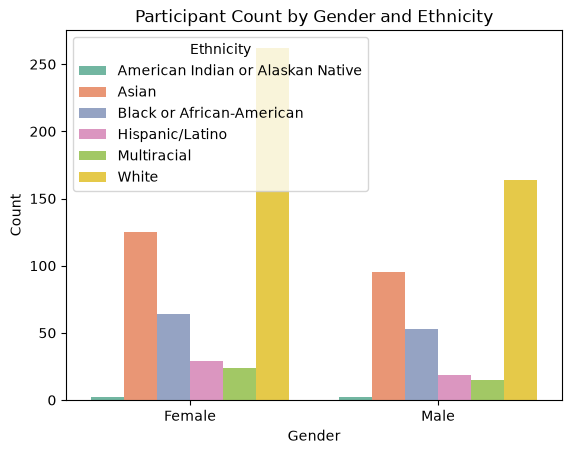

Gender
Female    506
Male      348
Name: count, dtype: int64


In [13]:
male_female_counts = (
    df[0].loc[df[0]["Gender"].notna(), ["Gender", "Subject_ID"]]
    .groupby("Gender")
    .count()
    .rename(columns={"Subject_ID": "Count"})
)

gender_ethnicity_counts = (
    df[0][df[0]["Gender"].notnull() & df[0]["Ethnicity"].notnull()]
    [["Subject_ID", "Gender", "Ethnicity"]]
    .groupby(["Gender", "Ethnicity"], as_index=False)
    .count()
    .rename(columns={"Subject_ID": "Count"})
)

plt.figure()

sns.barplot(
    data=gender_ethnicity_counts,
    x="Gender",
    y="Count",
    hue="Ethnicity",
    palette="Set2"
)

plt.title("Participant Count by Gender and Ethnicity")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Ethnicity")
plt.show()
male_female_counts = df[0]["Gender"].value_counts()

print(male_female_counts)

>**Insight:** The dataset contains more female observations than male observations. The distribution across ethnic groups is also uneven, with White and Asian participants contributing a larger number of observations than the remaining categories. Therefore, the categorical variables should be retained during preprocessing, while keeping the imbalance in the dataset in mind when interpreting the regression results.

5. For the first trial, we will do the following visualizations

    - Scatterplot between all features in the dataset
    - Boxplot of all features to identify outliers
    - Historgram to identify the shape of all the features
    - Heatmap to idenitfy correlations between all the features.

a) Boxplot

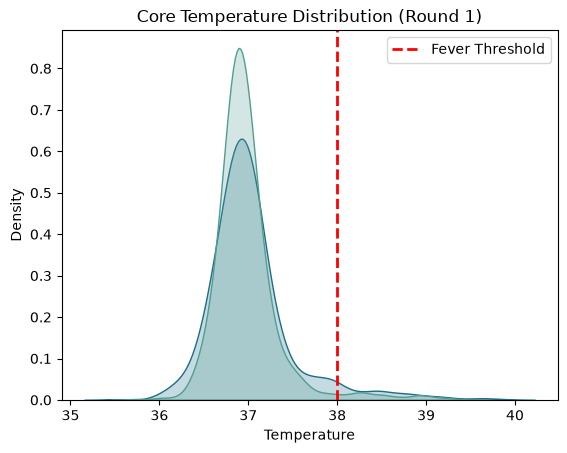

In [14]:
data = df[0].copy()

melted_data = data[['True_Core_Temp_Fast', 'True_Core_Temp_Slow']].melt(
    var_name='Sensor Type',
    value_name='Temperature'
)

plt.figure()

sns.kdeplot(
    data=melted_data,
    x='Temperature',
    hue='Sensor Type',
    fill=True,
    palette='crest'
)

fever_threshold = 38.0

plt.axvline(
    x=fever_threshold,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Fever Threshold'
)

plt.title('Core Temperature Distribution (Round 1)')
plt.xlabel('Temperature')
plt.legend()

plt.show()

>**Note:** The KDE plot compares the distributions of the Fast and Slow core-temperature measurements in Round 1. The 38°C reference line is included to identify observations above the selected temperature threshold.

>**Insight:** Both measurements are concentrated around the normal core-temperature range and show similar distribution patterns. A smaller number of observations extend beyond the 38°C reference threshold, which can be examined further during outlier analysis.

C:\Users\navee\AppData\Local\Temp\ipykernel_26644\4013461676.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted, x="Feature", y="Value", palette="Set3", ax=ax)
C:\Users\navee\AppData\Local\Temp\ipykernel_26644\4013461676.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted, x="Feature", y="Value", palette="Set3", ax=ax)
C:\Users\navee\AppData\Local\Temp\ipykernel_26644\4013461676.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted, x="Feature", y="Value", palette="Set3", ax=ax)
C:\Users\navee\AppData\Lo

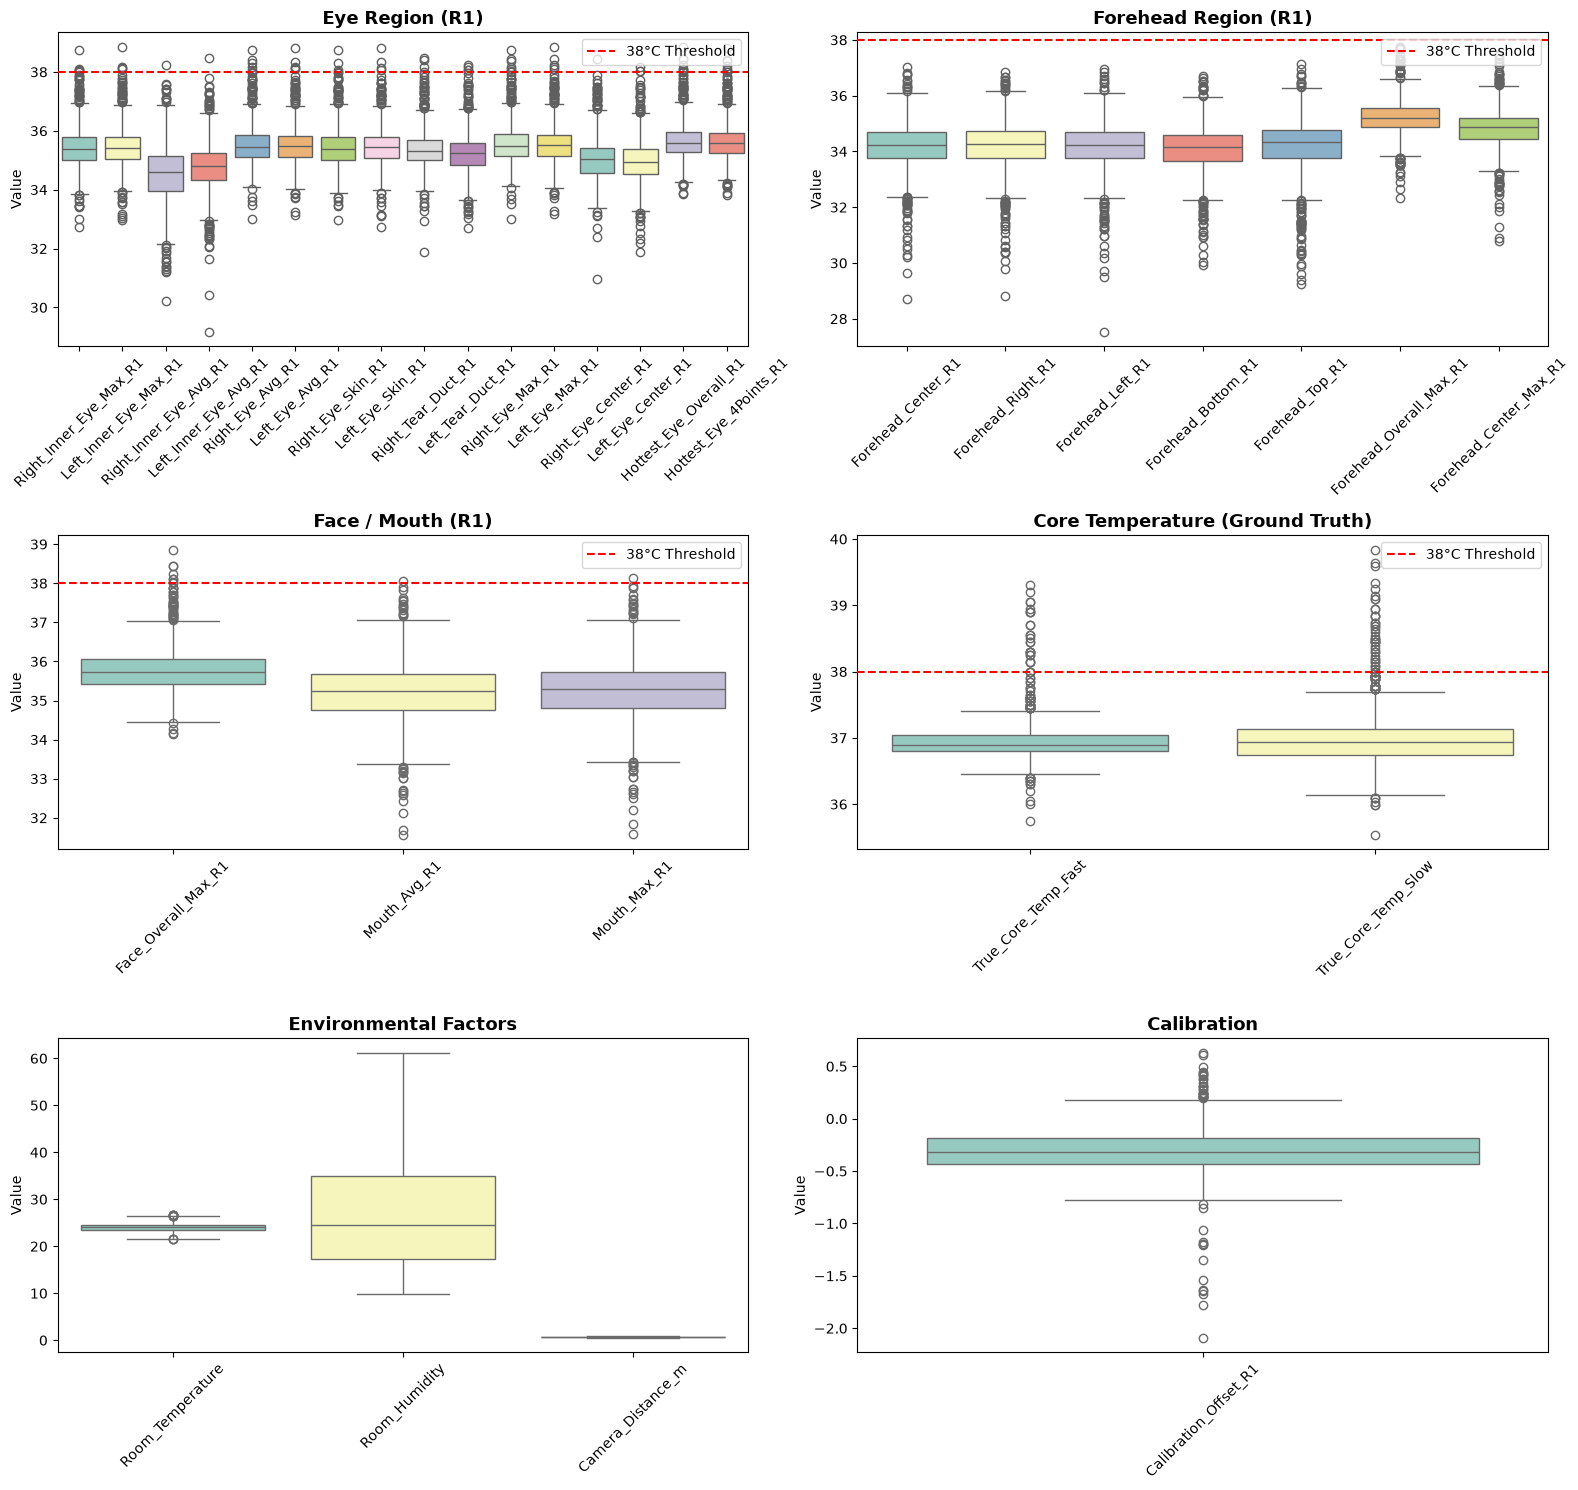

In [15]:
data = df[0].copy()

feature_groups = {
    "Eye Region (R1)": [
        'Right_Inner_Eye_Max_R1', 'Left_Inner_Eye_Max_R1',
        'Right_Inner_Eye_Avg_R1', 'Left_Inner_Eye_Avg_R1',
        'Right_Eye_Avg_R1', 'Left_Eye_Avg_R1',
        'Right_Eye_Skin_R1', 'Left_Eye_Skin_R1',
        'Right_Tear_Duct_R1', 'Left_Tear_Duct_R1',
        'Right_Eye_Max_R1', 'Left_Eye_Max_R1',
        'Right_Eye_Center_R1', 'Left_Eye_Center_R1',
        'Hottest_Eye_Overall_R1', 'Hottest_Eye_4Points_R1'
    ],
    "Forehead Region (R1)": [
        'Forehead_Center_R1', 'Forehead_Right_R1', 'Forehead_Left_R1',
        'Forehead_Bottom_R1', 'Forehead_Top_R1',
        'Forehead_Overall_Max_R1', 'Forehead_Center_Max_R1'
    ],
    "Face / Mouth (R1)": [
        'Face_Overall_Max_R1', 'Mouth_Avg_R1', 'Mouth_Max_R1'
    ],
    "Core Temperature (Ground Truth)": [
        'True_Core_Temp_Fast', 'True_Core_Temp_Slow'
    ],
    "Environmental Factors": [
        'Room_Temperature', 'Room_Humidity', 'Camera_Distance_m'
    ],
    "Calibration": [
        'Calibration_Offset_R1'
    ]
}

n_groups = len(feature_groups)
n_cols = 2
n_rows = (n_groups + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for ax, (group_name, cols) in zip(axes, feature_groups.items()):
    melted = data[cols].melt(var_name="Feature", value_name="Value")
    sns.boxplot(data=melted, x="Feature", y="Value", palette="Set3", ax=ax)
    if group_name not in ["Calibration", "Environmental Factors"]:
        ax.axhline(
            y=38.0, 
            color='red', 
            linestyle='--', 
            linewidth=1.5, 
            zorder=5, 
            label='38°C Threshold'
        )
        ax.legend(loc='upper right') 
    
    ax.set_title(group_name, fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=45)

for ax in axes[len(feature_groups):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

>**Note:** The features are divided into six meaningful regions: Eye Region, Forehead Region, Face/Mouth, Core Temperature, Environmental Factors, and Calibration. Outliers below the fever range should not automatically be removed because they may represent genuine lower thermal readings caused by facial location, environmental conditions, or natural measurement variation. 

>**Insight:** Removing them could eliminate valid information and reduce the model's ability to generalize to different temperature conditions.

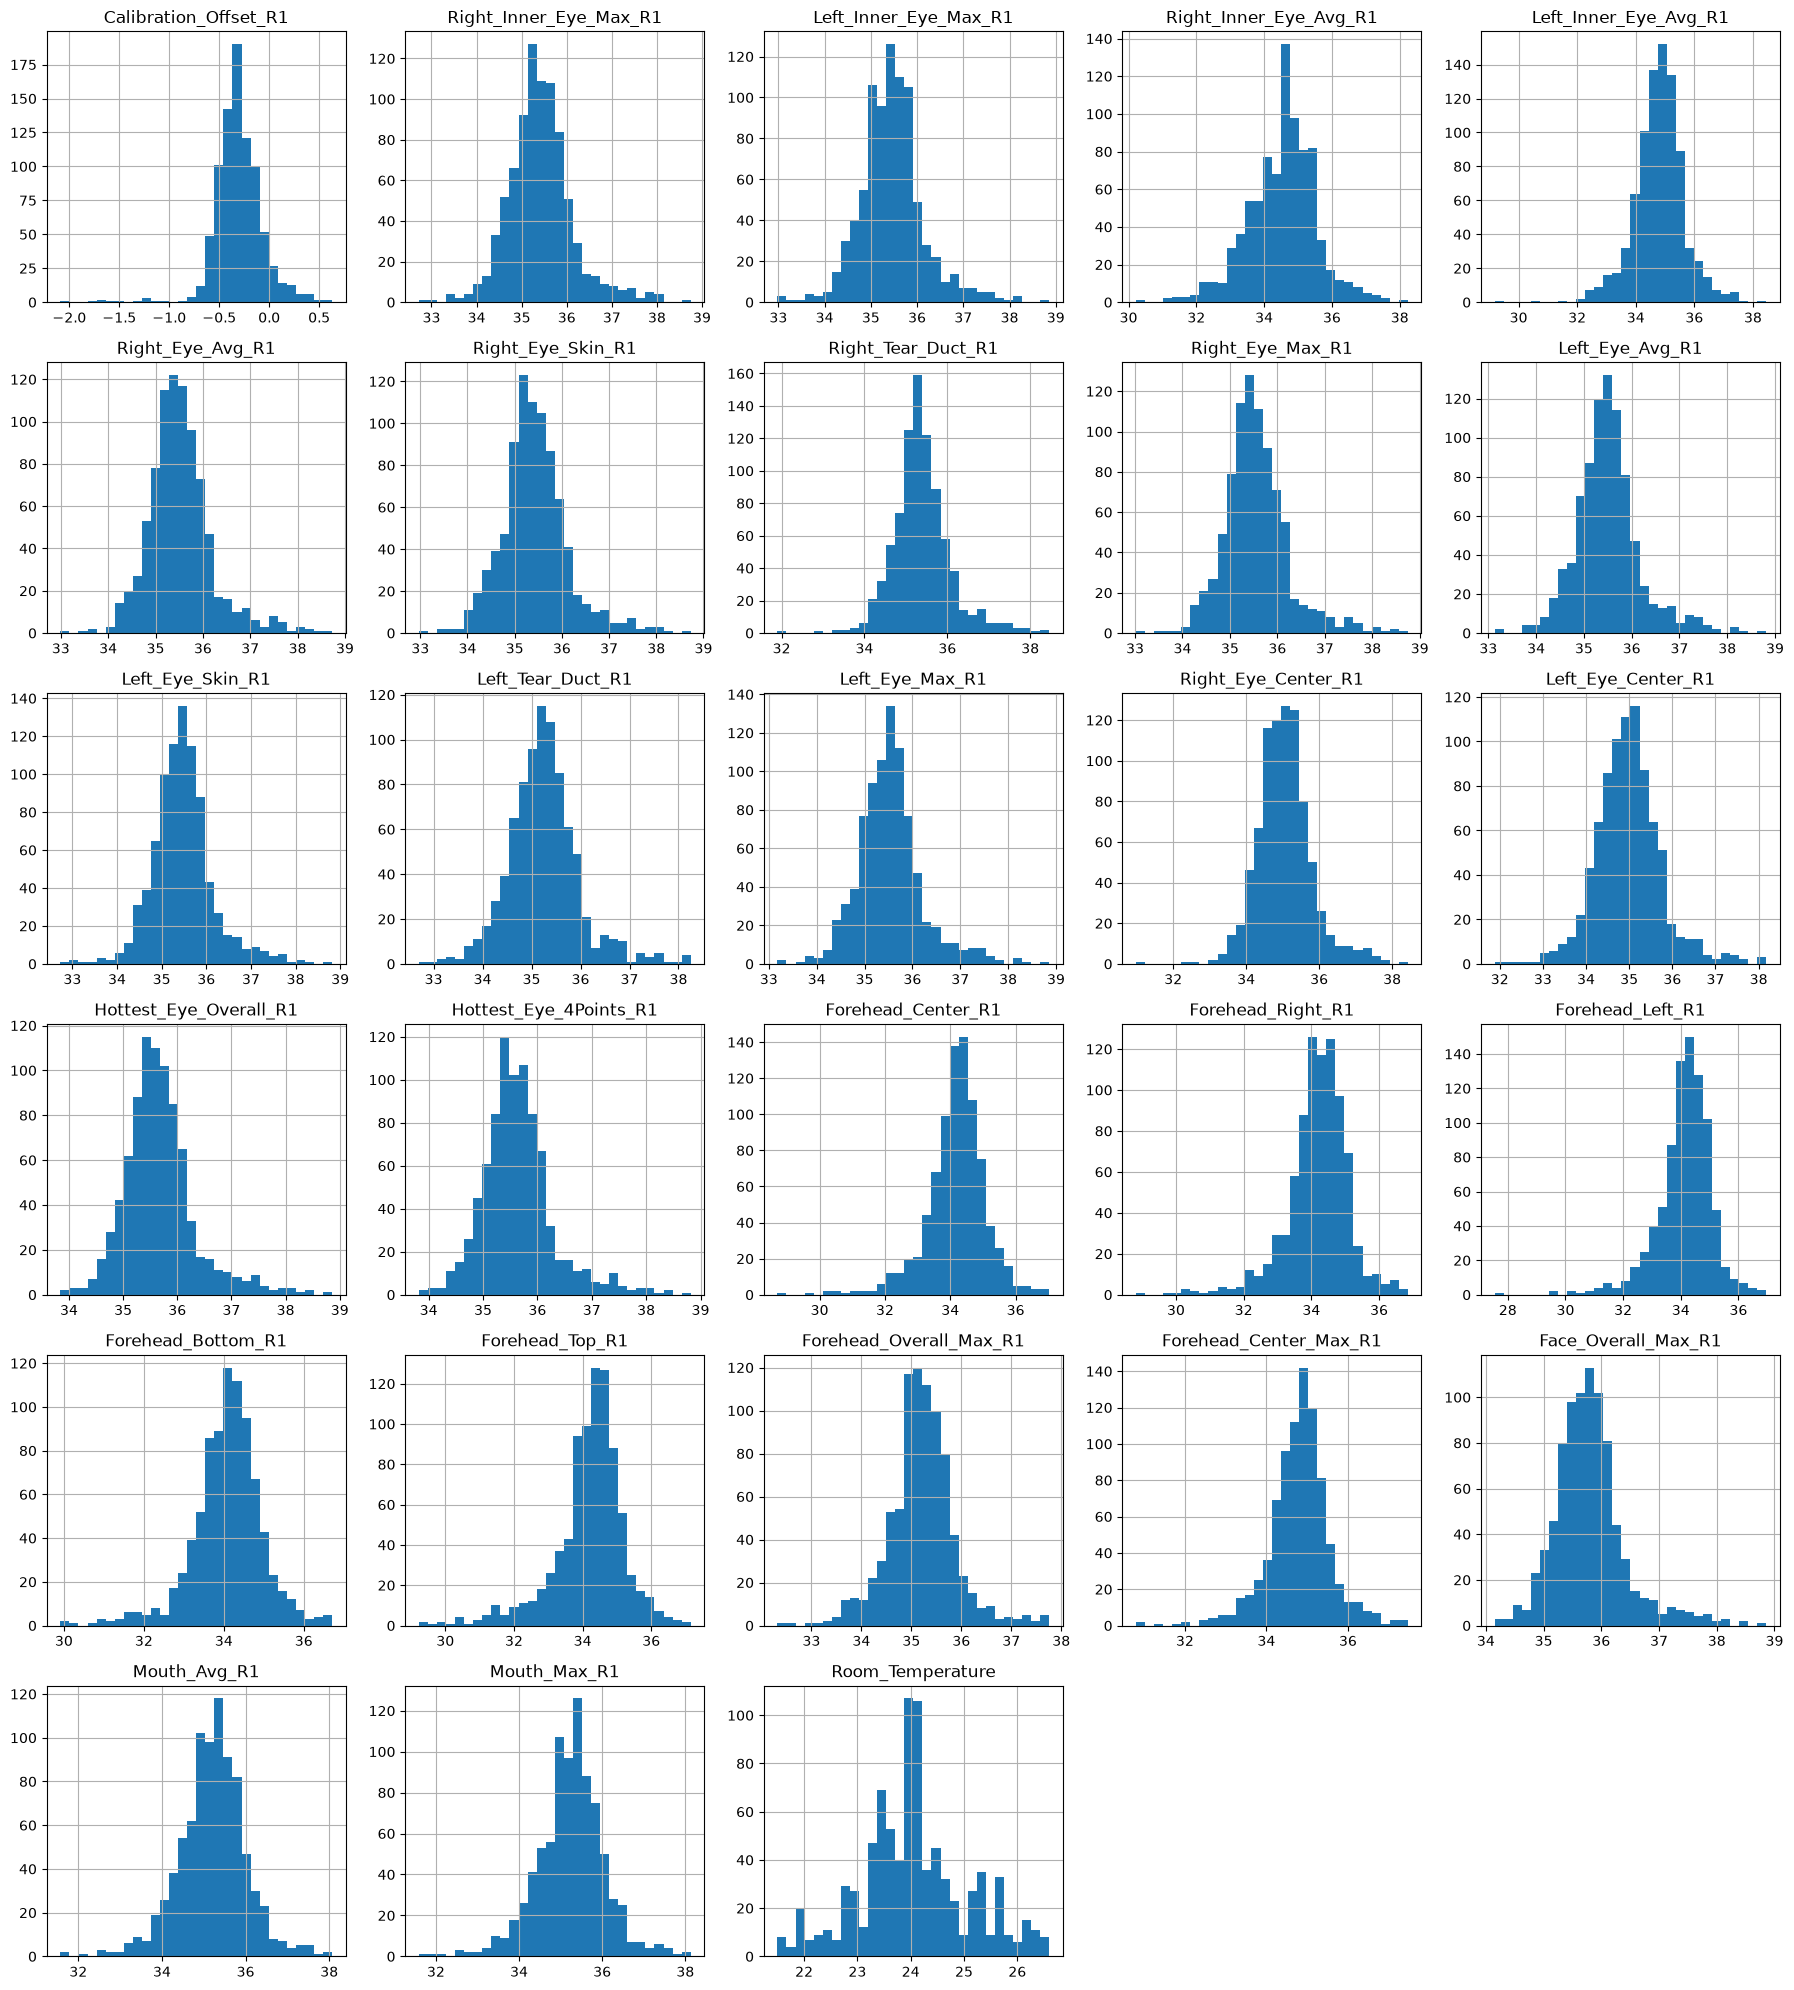

In [16]:

data = df[0].copy()

numeric_cols = data.select_dtypes(include=np.number).columns

feature_cols_eda = [
    col for col in numeric_cols
    if col not in ['True_Core_Temp_Fast', 'True_Core_Temp_Slow','Wearing_Makeup', 'Room_Humidity', 'Camera_Distance_m']
]

data[feature_cols_eda].hist(
    figsize=(18, 20),
    bins=30
)

plt.tight_layout()
plt.show()

>**Insight:** Most of the thermal features show concentrated distributions around their typical temperature ranges, with some features displaying skewness and extreme observations. The distributions help identify the general shape and spread of the features before applying further preprocessing and outlier handling.

Visualizing the target distribution

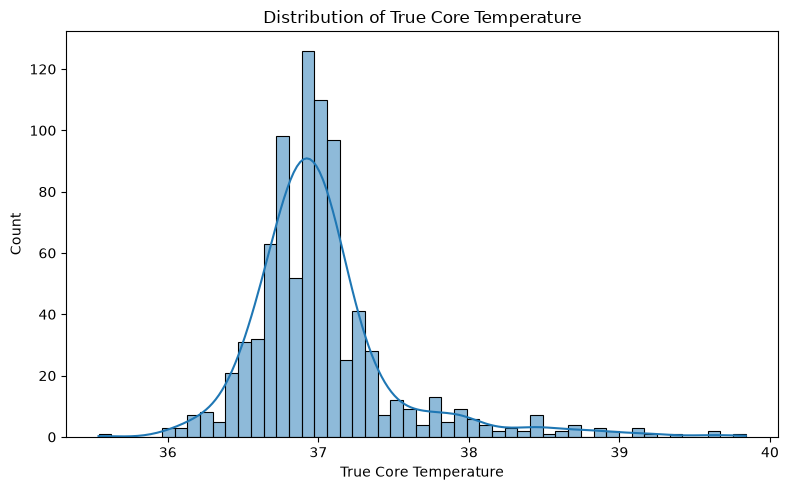

In [17]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=data,
    x='True_Core_Temp_Slow',
    kde=True
)

plt.title("Distribution of True Core Temperature")
plt.xlabel("True Core Temperature")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

>**Insight:** The distribution shows that most of the participants recorded during testing have normal core temperatures, with the majority of observations concentrated around 37°C. Only a relatively small number of participants have higher temperatures, which generally is the case in real life testing scenarios.

b) Scatterplots

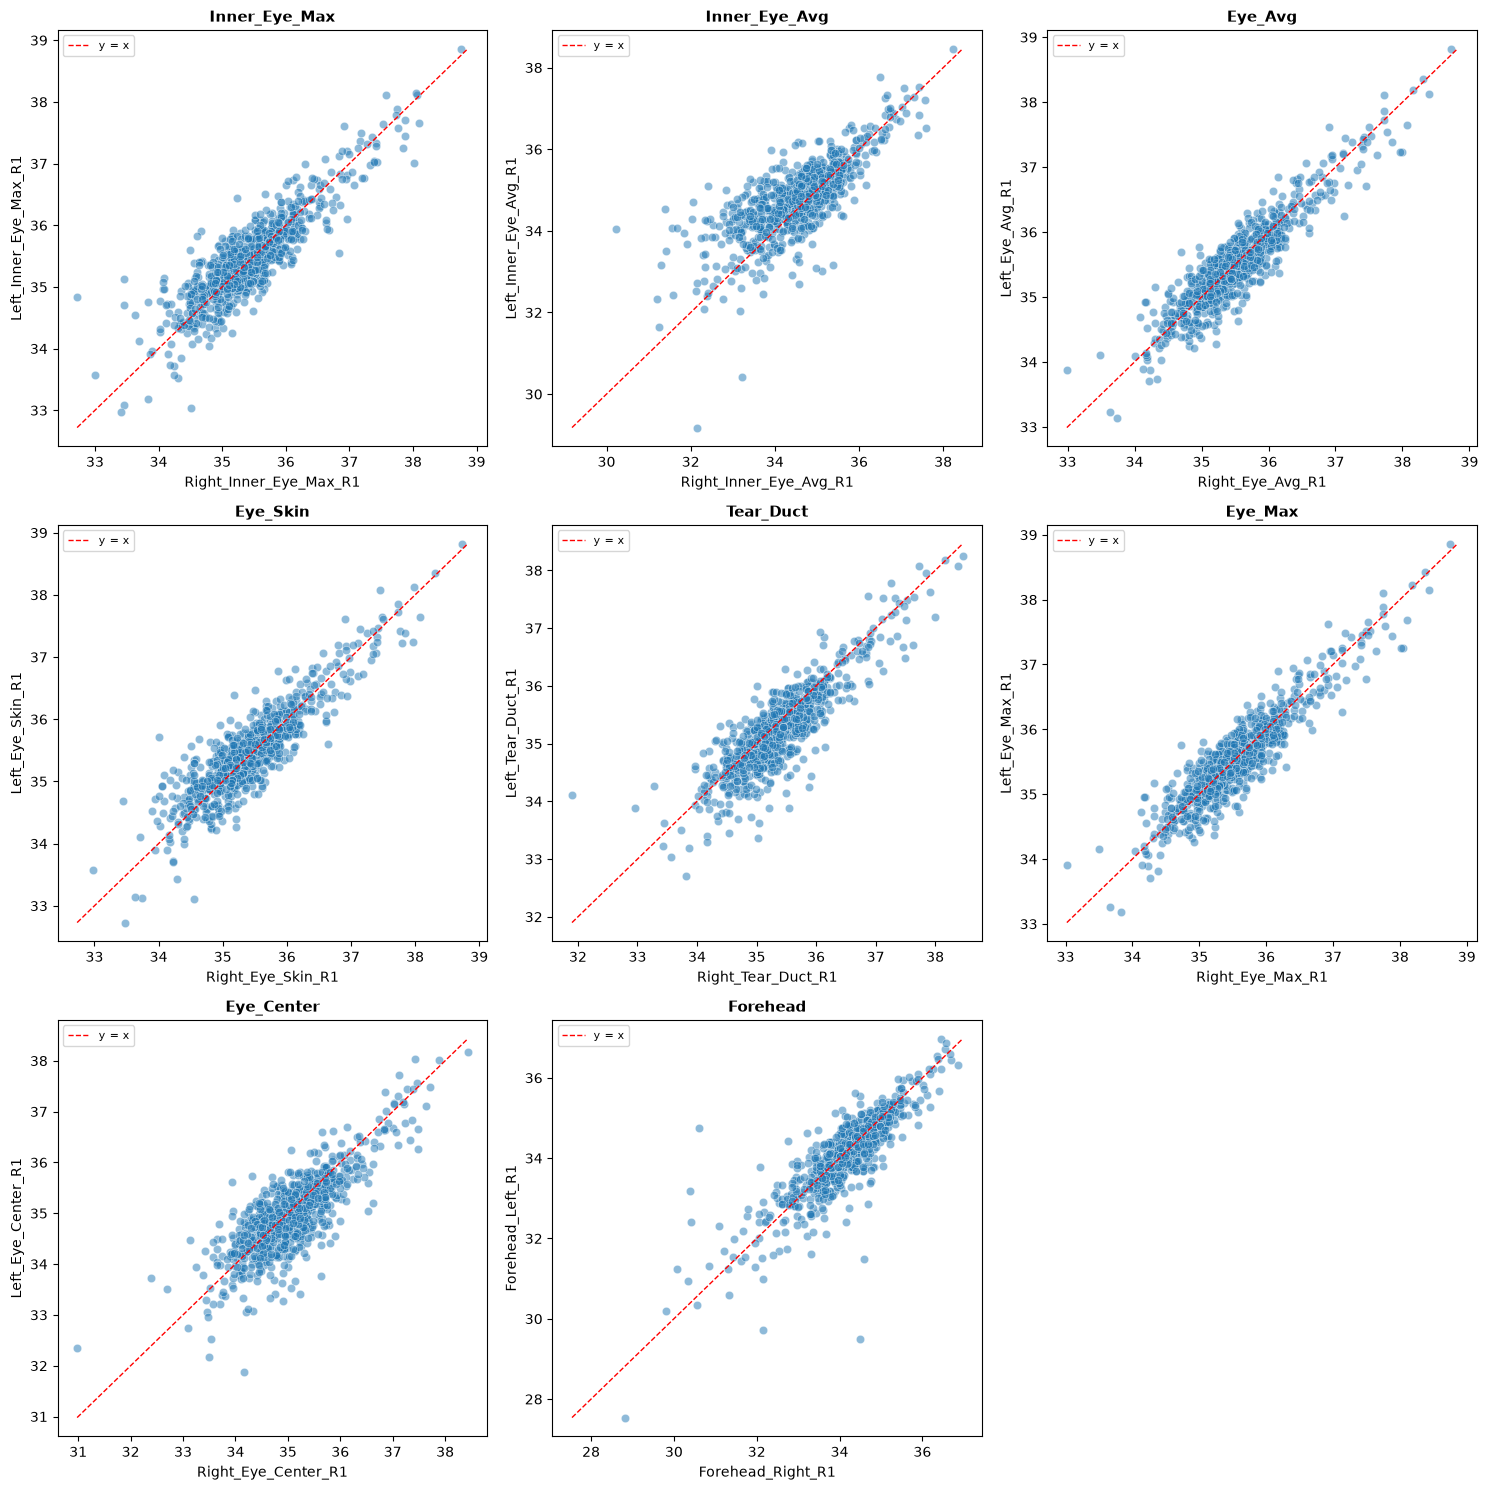

In [18]:
data = df[0].copy()

# Paired Right vs Left columns (symmetric measurements)
pairs = [
    ('Right_Inner_Eye_Max_R1', 'Left_Inner_Eye_Max_R1'),
    ('Right_Inner_Eye_Avg_R1', 'Left_Inner_Eye_Avg_R1'),
    ('Right_Eye_Avg_R1',       'Left_Eye_Avg_R1'),
    ('Right_Eye_Skin_R1',      'Left_Eye_Skin_R1'),
    ('Right_Tear_Duct_R1',     'Left_Tear_Duct_R1'),
    ('Right_Eye_Max_R1',       'Left_Eye_Max_R1'),
    ('Right_Eye_Center_R1',    'Left_Eye_Center_R1'),
    ('Forehead_Right_R1',      'Forehead_Left_R1'),
]

n_cols = 3
n_rows = -(-len(pairs) // n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(15, 5 * n_rows)
)

axes = axes.flatten()

for ax, (right_col, left_col) in zip(axes, pairs):

    sns.scatterplot(
        data=data,
        x=right_col,
        y=left_col,
        alpha=0.5,
        ax=ax
    )

    # y = x reference line to visualize perfect symmetry
    lims = [
        min(data[right_col].min(), data[left_col].min()),
        max(data[right_col].max(), data[left_col].max())
    ]

    ax.plot(
        lims,
        lims,
        'r--',
        linewidth=1,
        label='y = x'
    )

    ax.set_title(
        right_col.replace('Right_', '').replace('_R1', ''),
        fontsize=11,
        fontweight='bold'
    )

    ax.set_xlabel(right_col)
    ax.set_ylabel(left_col)
    ax.legend(fontsize=8)

# Hide unused axes
for ax in axes[len(pairs):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

>**Insight:** The right-side and left-side thermal measurements show strong positive relationships, with most observations lying close to the y = x reference line. This indicates that corresponding measurements from both sides of the face are generally similar, suggesting considerable redundancy among these features.

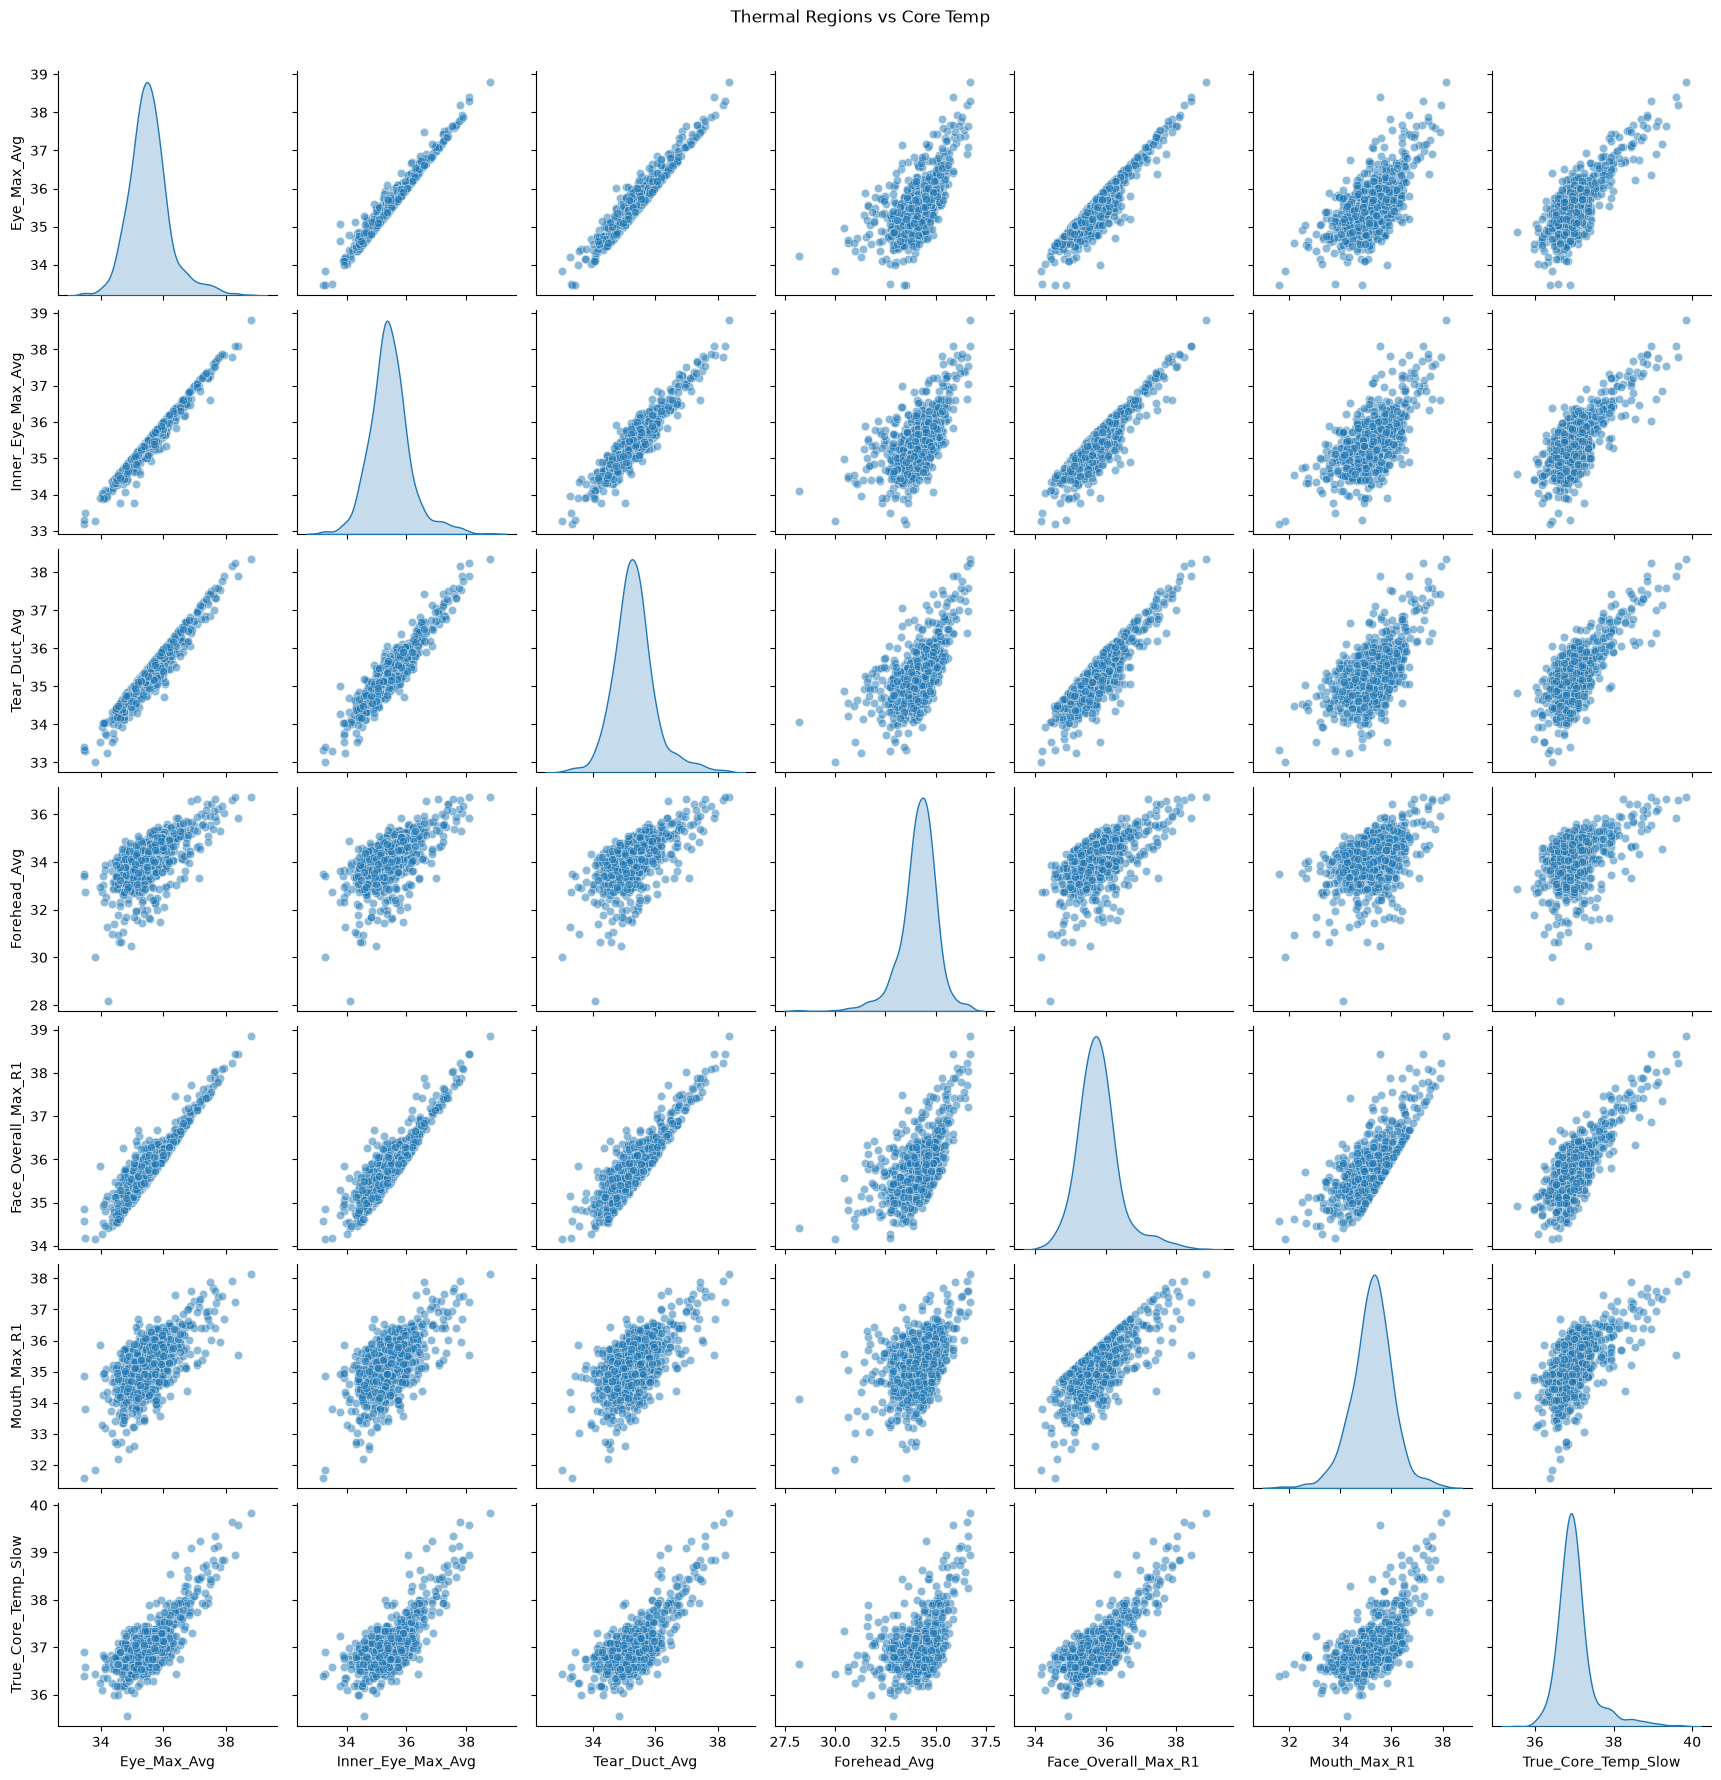

In [19]:
data_p = data.copy()

# Average left/right 
data_p['Eye_Max_Avg']       = data_p[['Right_Eye_Max_R1', 'Left_Eye_Max_R1']].mean(axis=1)
data_p['Inner_Eye_Max_Avg'] = data_p[['Right_Inner_Eye_Max_R1', 'Left_Inner_Eye_Max_R1']].mean(axis=1)
data_p['Tear_Duct_Avg']     = data_p[['Right_Tear_Duct_R1', 'Left_Tear_Duct_R1']].mean(axis=1)
data_p['Forehead_Avg']      = data_p[['Forehead_Right_R1', 'Forehead_Left_R1']].mean(axis=1)

cols = ['Eye_Max_Avg', 'Inner_Eye_Max_Avg', 'Tear_Duct_Avg', 'Forehead_Avg',
        'Face_Overall_Max_R1', 'Mouth_Max_R1', 'True_Core_Temp_Slow']

sns.pairplot(data_p[cols], kind='scatter', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle("Thermal Regions vs Core Temp", y=1.02)
plt.show()

The forehead and mouth temperature features show comparatively lower correlations with the true core temperature, with more scattered relationships than the eye-region features.

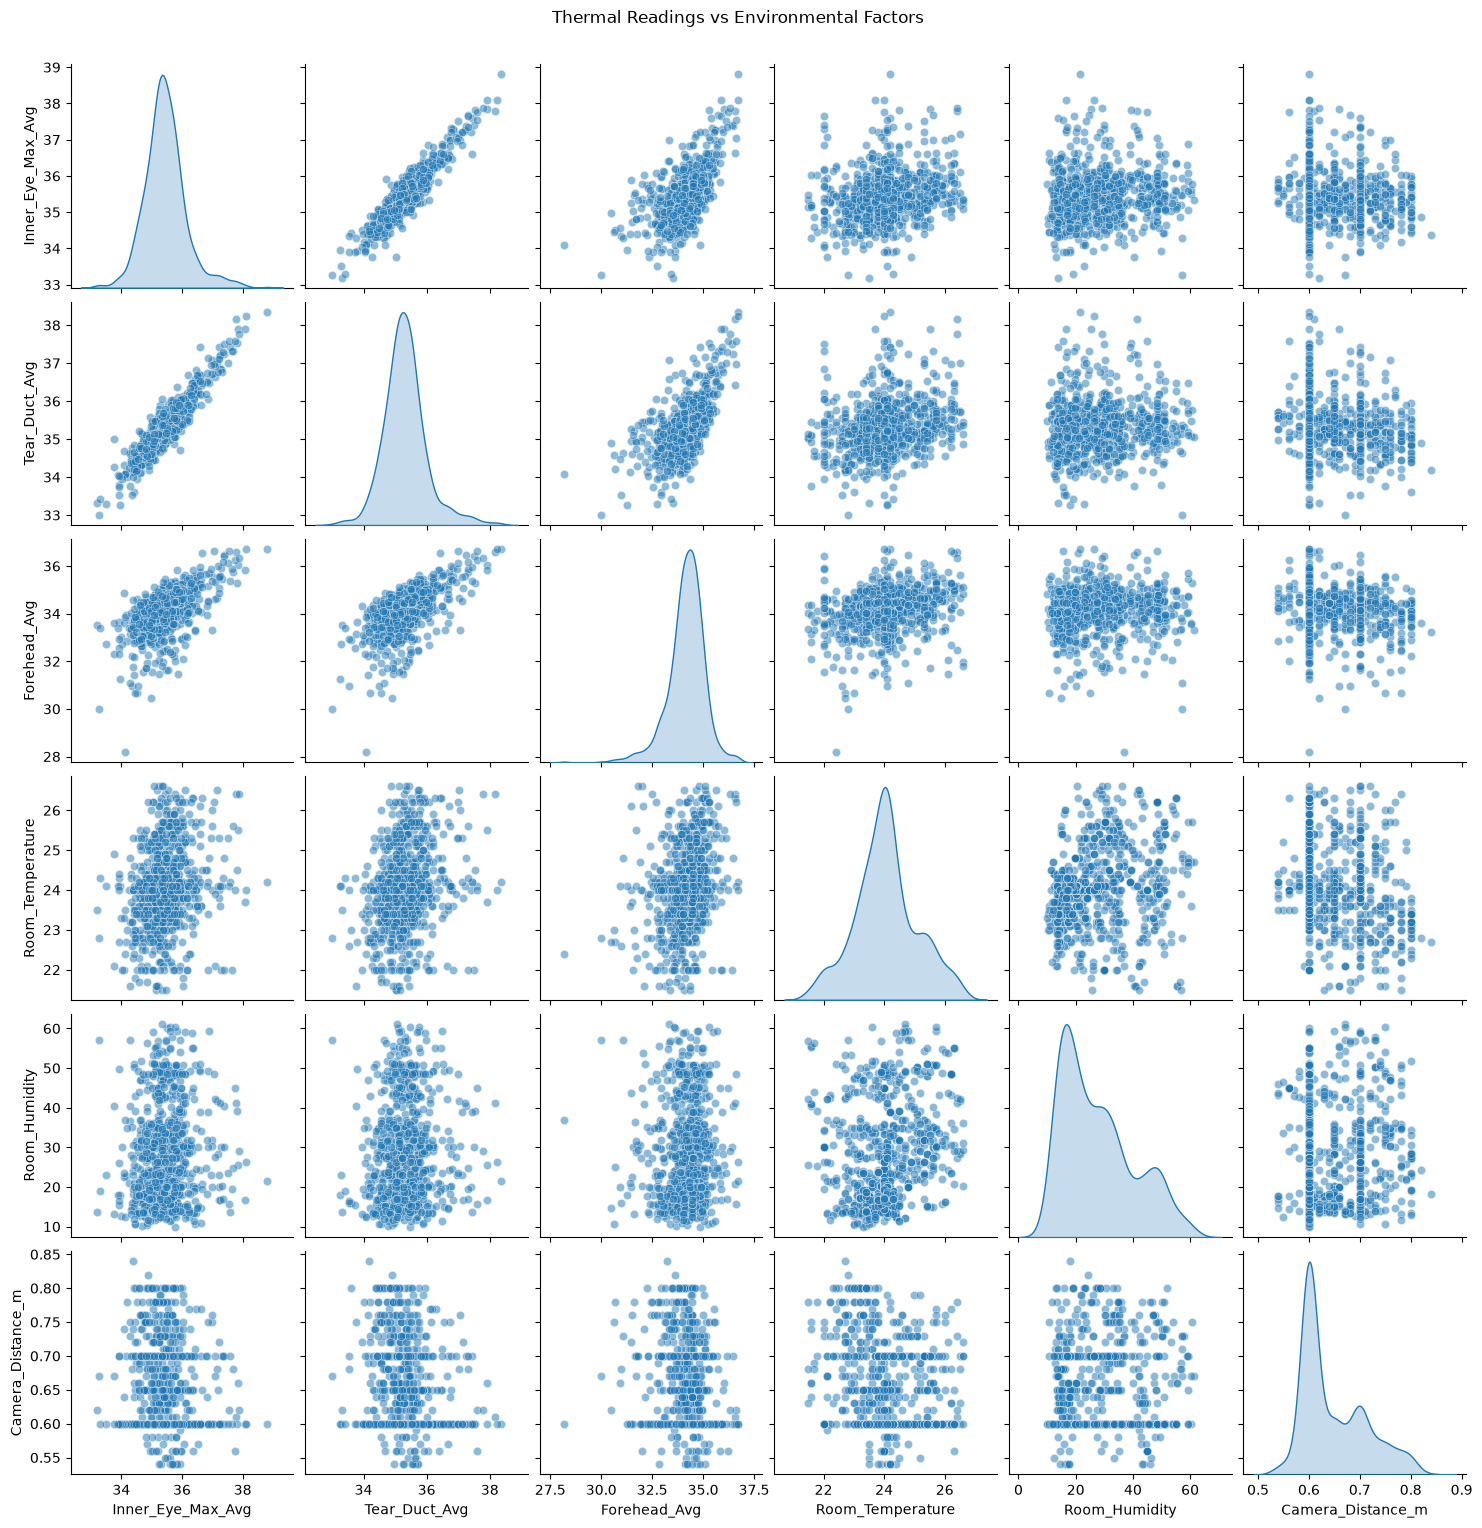

In [20]:
env_cols = ['Inner_Eye_Max_Avg', 'Tear_Duct_Avg', 'Forehead_Avg',
            'Room_Temperature', 'Room_Humidity', 'Camera_Distance_m']

sns.pairplot(data_p[env_cols], kind='scatter', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle("Thermal Readings vs Environmental Factors", y=1.02)
plt.show()

>**Insight:** The repeated horizontal and vertical patterns in the plots suggest that many observations were recorded under similar or repeated environmental conditions, particularly for room temperature, humidity, and camera distance.

Scatter plots which show feature Target Relationships

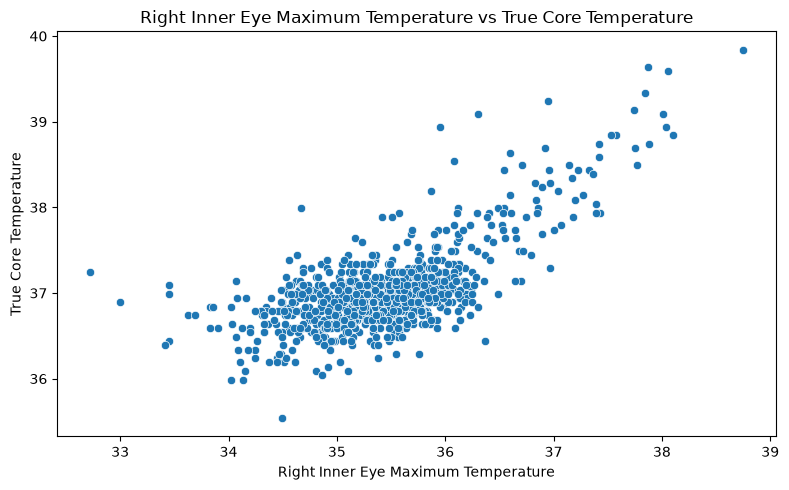

In [21]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data,
    x='Right_Inner_Eye_Max_R1',
    y='True_Core_Temp_Slow'
)

plt.title("Right Inner Eye Maximum Temperature vs True Core Temperature")
plt.xlabel("Right Inner Eye Maximum Temperature")
plt.ylabel("True Core Temperature")

plt.tight_layout()
plt.show()

>**Insight:** The relationship is positive, but there is still substantial scatter, especially around the main cluster. The feature has some predictive information, but it does not map cleanly to core temperature by itself.

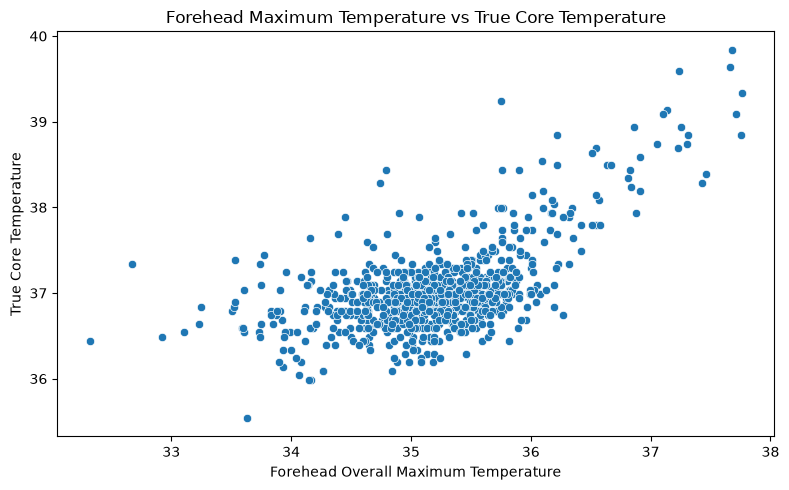

In [22]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data,
    x='Forehead_Overall_Max_R1',
    y='True_Core_Temp_Slow'
)

plt.title("Forehead Maximum Temperature vs True Core Temperature")
plt.xlabel("Forehead Overall Maximum Temperature")
plt.ylabel("True Core Temperature")

plt.tight_layout()
plt.show()

>**Insight:** The forehead temperature shows greater scatter and less consistent variation with the target, indicating that it is a relatively weaker predictor compared with the inner-eye temperature.

GroupShufflSplit for test/train split for modelling

In [23]:
from sklearn.model_selection import GroupShuffleSplit

# Make copies of all 4 processed rounds
r1 = df[0].copy()
r2 = df[1].copy()
r3 = df[2].copy()
r4 = df[3].copy()

# Remove round suffixes
r1.columns = r1.columns.str.replace('_R1', '', regex=False)
r2.columns = r2.columns.str.replace('_R2', '', regex=False)
r3.columns = r3.columns.str.replace('_R3', '', regex=False)
r4.columns = r4.columns.str.replace('_R4', '', regex=False)

# Combine all rounds
full_data = pd.concat([r1, r2, r3, r4], ignore_index=True)

# Split by Subject_ID
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(full_data, groups=full_data['Subject_ID'])
)

train_data = full_data.iloc[train_idx].copy()
test_data = full_data.iloc[test_idx].copy()

print("Full data:", full_data.shape)
print("Training:", train_data.shape)
print("Testing:", test_data.shape)
print("Training subjects:", train_data['Subject_ID'].nunique())
print("Testing subjects:", test_data['Subject_ID'].nunique())

Full data: (3206, 39)
Training: (2550, 39)
Testing: (656, 39)
Training subjects: 720
Testing subjects: 181


Drop features based on correlation values

In [24]:
numerical_features = [
    'Calibration_Offset', 'Right_Inner_Eye_Max',
    'Left_Inner_Eye_Max', 'Right_Inner_Eye_Avg',
    'Left_Inner_Eye_Avg', 'Right_Eye_Avg',
    'Right_Eye_Skin', 'Right_Tear_Duct', 'Right_Eye_Max',
    'Left_Eye_Avg', 'Left_Eye_Skin', 'Left_Tear_Duct',
    'Left_Eye_Max', 'Right_Eye_Center', 'Left_Eye_Center',
    'Hottest_Eye_Overall', 'Hottest_Eye_4Points',
    'Forehead_Center', 'Forehead_Right', 'Forehead_Left',
    'Forehead_Bottom', 'Forehead_Top',
    'Forehead_Overall_Max', 'Forehead_Center_Max',
    'Face_Overall_Max', 'Mouth_Avg', 'Mouth_Max',
    'Room_Temperature', 'Room_Humidity', 'Camera_Distance_m'
]

threshold = 0.9


corr_matrix = train_data[numerical_features].corr().abs()

# Upper triangle
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find highly correlated features
to_drop = [
    col for col in upper_triangle.columns
    if any(upper_triangle[col] > threshold)
]

print(f"Features to drop ({len(to_drop)}):")
print(to_drop)

# Drop the same features from both datasets
train_data = train_data.drop(columns=to_drop)
test_data = test_data.drop(columns=to_drop)

print(f"\nTraining features remaining: {train_data.shape[1]}")
print(f"Testing features remaining: {test_data.shape[1]}")
print("\nRemaining columns:")
for i, col in enumerate(train_data.columns, 1):
    print(f"{i}. {col}")


Features to drop (15):
['Right_Eye_Avg', 'Right_Eye_Skin', 'Right_Tear_Duct', 'Right_Eye_Max', 'Left_Eye_Avg', 'Left_Eye_Skin', 'Left_Tear_Duct', 'Left_Eye_Max', 'Right_Eye_Center', 'Left_Eye_Center', 'Hottest_Eye_Overall', 'Hottest_Eye_4Points', 'Forehead_Bottom', 'Forehead_Center_Max', 'Mouth_Max']

Training features remaining: 24
Testing features remaining: 24

Remaining columns:
1. Subject_ID
2. Calibration_Offset
3. Right_Inner_Eye_Max
4. Left_Inner_Eye_Max
5. Right_Inner_Eye_Avg
6. Left_Inner_Eye_Avg
7. Forehead_Center
8. Forehead_Right
9. Forehead_Left
10. Forehead_Top
11. Forehead_Overall_Max
12. Face_Overall_Max
13. Mouth_Avg
14. True_Core_Temp_Fast
15. True_Core_Temp_Slow
16. Gender
17. Age
18. Ethnicity
19. Room_Temperature
20. Room_Humidity
21. Camera_Distance_m
22. Wearing_Makeup
23. Time
24. Date


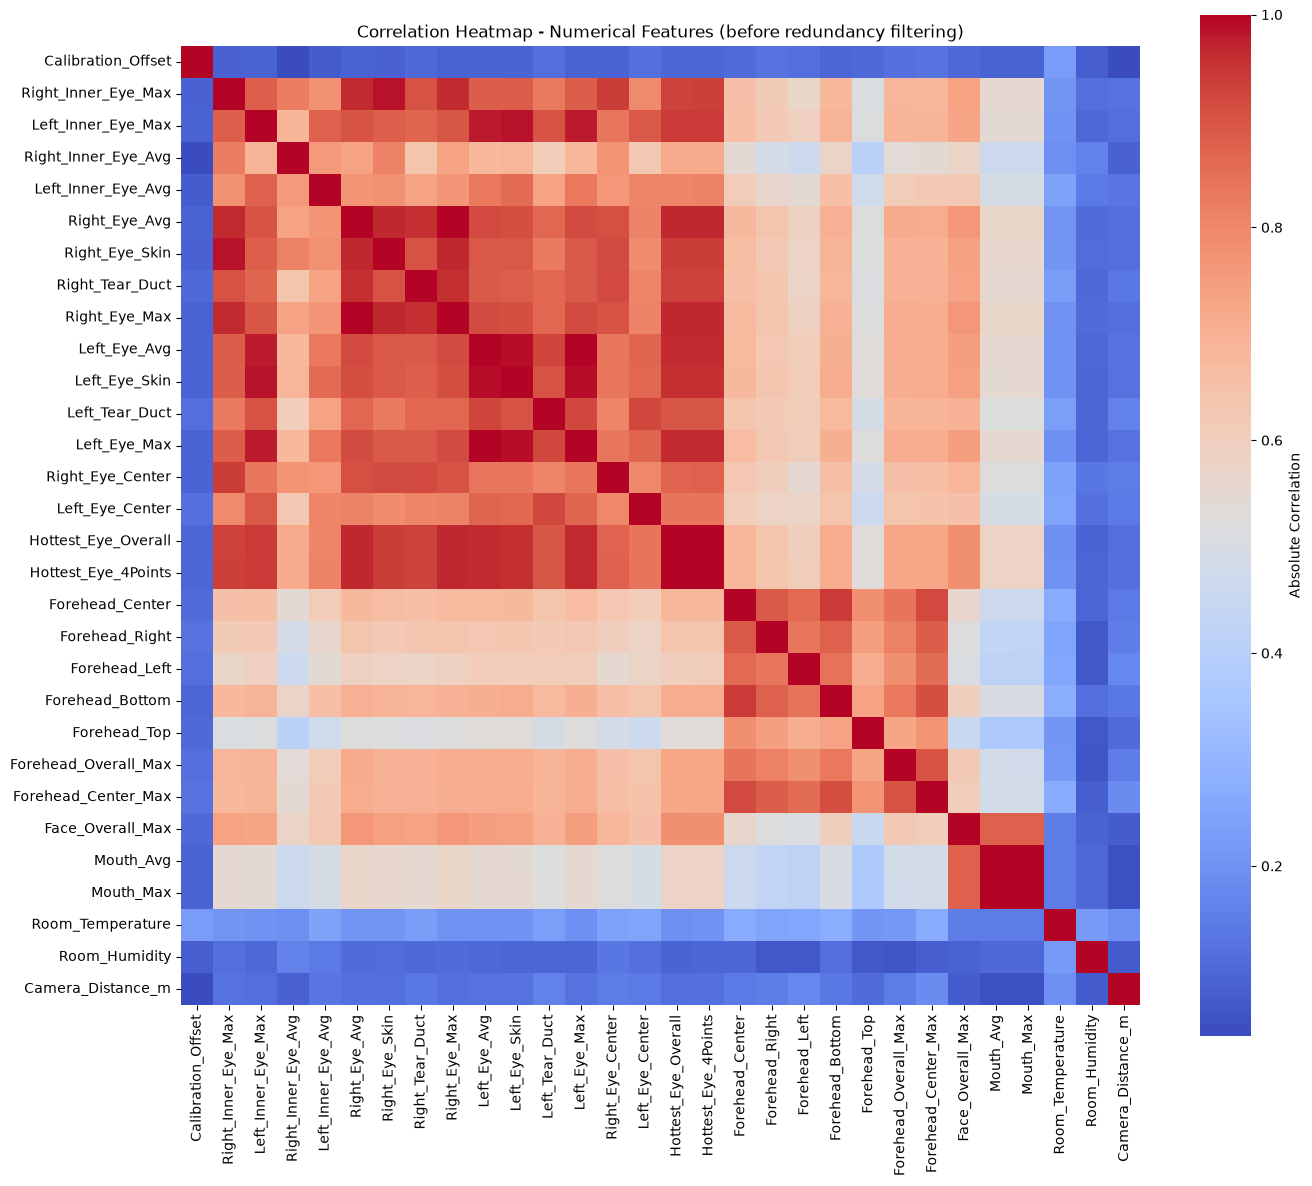

In [25]:
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, square=True,
            cbar_kws={'label': 'Absolute Correlation'})
plt.title("Correlation Heatmap - Numerical Features (before redundancy filtering)")
plt.tight_layout()
plt.show()

>**Insight:** The heatmap shows strong correlations among the eye-region features and moderate-to-strong correlations among the forehead features, indicating considerable redundancy. In contrast, the environmental features have relatively weak correlations with the thermal measurements. Therefore, highly correlated features can be filtered to reduce redundancy and multicollinearity before model development.

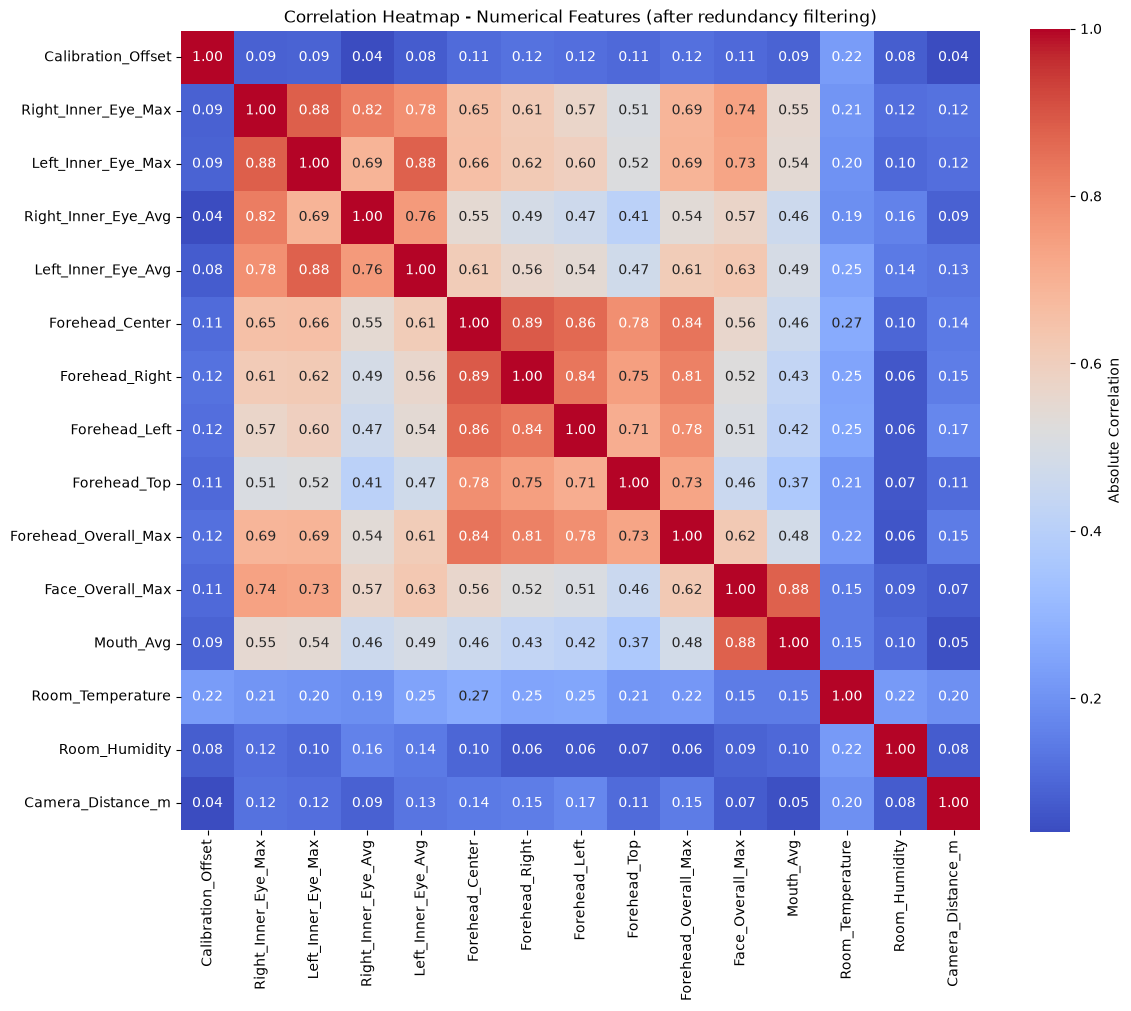

In [26]:
remaining_features = [col for col in numerical_features if col not in to_drop]

corr_matrix_after = train_data[remaining_features].corr().abs()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix_after,
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    square=True,
    cbar_kws={'label': 'Absolute Correlation'}
)
plt.title("Correlation Heatmap - Numerical Features (after redundancy filtering)")
plt.tight_layout()
plt.show()

PC1 explains 49.16% of variance
Correlation between PC1 and True Core Temp (Slow): 0.704


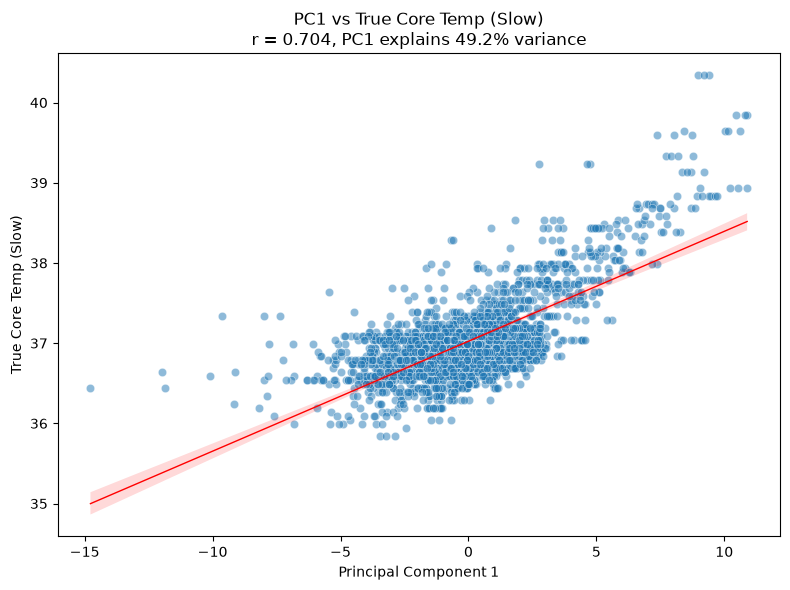

In [27]:

data = train_data.copy()

feature_cols = [
    'Calibration_Offset',
    'Right_Inner_Eye_Max',
    'Left_Inner_Eye_Max',
    'Right_Inner_Eye_Avg',
    'Left_Inner_Eye_Avg',
    'Forehead_Center',
    'Forehead_Right',
    'Forehead_Left',
    'Forehead_Top',
    'Forehead_Overall_Max',
    'Mouth_Avg',
    'Room_Temperature',
    'Room_Humidity',
    'Camera_Distance_m',
    
]

X = data[feature_cols].dropna()

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA
pca = PCA()
pca_result = pca.fit_transform(X_scaled)

# Add PC1 to corresponding rows
data_pca = data.loc[X.index].copy()
data_pca['PC1'] = pca_result[:, 0]

# Variance explained by PC1
pc1_variance = pca.explained_variance_ratio_[0] * 100

print(f"PC1 explains {pc1_variance:.2f}% of variance")

# Correlation between PC1 and Slow Core Temperature
corr = data_pca['PC1'].corr(
    data_pca['True_Core_Temp_Slow']
)

print(f"Correlation between PC1 and True Core Temp (Slow): {corr:.3f}")

# Plot PC1 vs Slow Core Temperature
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=data_pca,
    x='PC1',
    y='True_Core_Temp_Slow',
    alpha=0.5
)

sns.regplot(
    data=data_pca,
    x='PC1',
    y='True_Core_Temp_Slow',
    scatter=False,
    color='red',
    line_kws={'linewidth': 1}
)

plt.title(
    f"PC1 vs True Core Temp (Slow)\n"
    f"r = {corr:.3f}, "
    f"PC1 explains {pc1_variance:.1f}% variance"
)

plt.xlabel("Principal Component 1")
plt.ylabel("True Core Temp (Slow)")

plt.tight_layout()
plt.show()

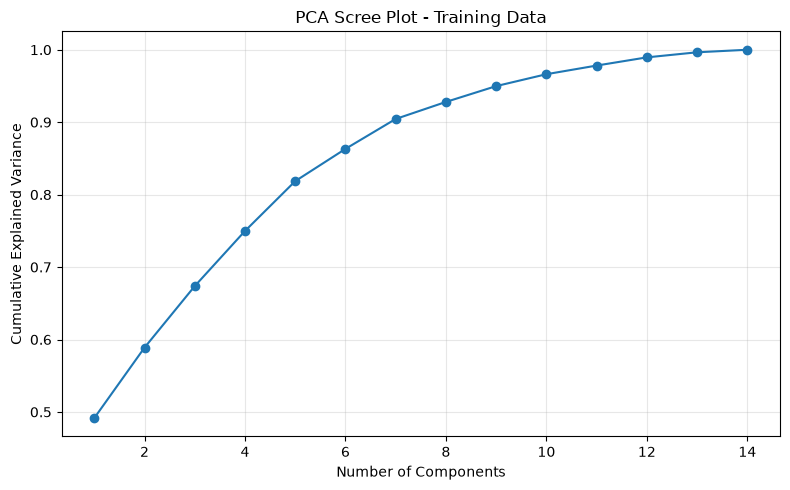

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    np.cumsum(pca.explained_variance_ratio_),
    marker='o'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot - Training Data")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

>**Insight:** The scree plot shows that a large number of principal components are required to retain most of the variance, with around 10 components needed to capture approximately 97% of the variance. Since PCA would transform the original features into less interpretable components while still requiring many components, we avoid PCA and retain the original features for better interpretability in the regression models.

In [29]:
# Training and testing data were split by Subject_ID
# using an 80/20 GroupShuffleSplit

feature_cols = [
    'Calibration_Offset',
    'Right_Inner_Eye_Max',
    'Left_Inner_Eye_Max',
    'Right_Inner_Eye_Avg',
    'Left_Inner_Eye_Avg',
    'Forehead_Center',
    'Forehead_Right',
    'Forehead_Left',
    'Forehead_Top',
    'Forehead_Overall_Max',
    'Mouth_Avg',
    'Room_Temperature',
    'Room_Humidity',
    'Camera_Distance_m',
    'Gender',
    'Ethnicity',
    'Wearing_Makeup'
]

target_col = 'True_Core_Temp_Slow'

train_groups = train_data['Subject_ID'].copy()

# Keep only features and target
train_model_data = train_data[feature_cols + [target_col]].copy()
test_model_data = test_data[feature_cols + [target_col]].copy()

# Remove rows containing missing values
train_valid = train_model_data.notna().all(axis=1)
test_valid = test_model_data.notna().all(axis=1)

train_model_data = train_model_data[train_valid].copy()
test_model_data = test_model_data[test_valid].copy()

# Keep groups aligned with training rows
train_groups = train_groups.loc[train_model_data.index]

# Separate features and target
X_train = train_model_data[feature_cols]
y_train = train_model_data[target_col]

X_test = test_model_data[feature_cols]
y_test = test_model_data[target_col]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Training subjects: {train_groups.nunique()}")

# Numerical columns
numerical_cols = [
    'Calibration_Offset',
    'Right_Inner_Eye_Max',
    'Left_Inner_Eye_Max',
    'Right_Inner_Eye_Avg',
    'Left_Inner_Eye_Avg',
    'Forehead_Center',
    'Forehead_Right',
    'Forehead_Left',
    'Forehead_Top',
    'Forehead_Overall_Max',
    'Mouth_Avg',
    'Room_Temperature',
    'Room_Humidity',
    'Camera_Distance_m'
]

# Categorical columns
categorical_cols = [
    'Gender',
    'Ethnicity',
    'Wearing_Makeup'
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(
            drop='first',
            handle_unknown='ignore'
        ), categorical_cols)
    ]
)

# Fit ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data
X_test_processed = preprocessor.transform(X_test)

# Names of processed features
encoded_feature_names = preprocessor.get_feature_names_out()

print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)
print("Number of processed features:", len(encoded_feature_names))

Training samples: 2550
Testing samples: 656
Training subjects: 720
Training shape: (2550, 21)
Testing shape: (656, 21)
Number of processed features: 21


>**Insight:** Numerical features are standardized to bring them to a common scale, while categorical features are one-hot encoded to convert them into suitable numerical representations without imposing any artificial order.

## Regression Models

In [30]:
group_cv = GroupKFold(n_splits=5)
all_results = []

def report_metrics(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{name}")
    print(f"  R²   : {r2:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    return {"Model": name, "R2": r2, "RMSE": rmse, "MAE": mae}

tuning_improvements = []

def report_tuning_improvement(name, default_model, tuned_model, X_tr, y_tr, X_te, y_te, best_params):
    default_model.fit(X_tr, y_tr)
    r2_before = r2_score(y_te, default_model.predict(X_te))
    r2_after = r2_score(y_te, tuned_model.predict(X_te))

    print(f"{name}")
    print(f"  Best params        : {best_params}")
    print(f"  Test R² (default)  : {r2_before:.4f}")
    print(f"  Test R² (tuned)    : {r2_after:.4f}")
    print(f"  Improvement        : {r2_after - r2_before:+.4f}")

    tuning_improvements.append({
        "Model": name,
        "Best Params": best_params,
        "R2 Default": r2_before,
        "R2 Tuned": r2_after,
        "Improvement": r2_after - r2_before
    })

### 1. Linear Regression

In [31]:
linear_model = LinearRegression()
linear_model.fit(X_train_processed, y_train)
y_pred_linear = linear_model.predict(X_test_processed)

all_results.append(report_metrics("Linear Regression", y_test, y_pred_linear))

coef_df = pd.DataFrame({
    "Feature": encoded_feature_names,
    "Coefficient": linear_model.coef_
}).sort_values(by="Coefficient", key=np.abs, ascending=False)

print("\nTop coefficients (by magnitude):")
print(coef_df.head(10))

Linear Regression
  R²   : 0.5395
  RMSE : 0.3301
  MAE  : 0.2516

Top coefficients (by magnitude):
                                     Feature  Coefficient
2                    num__Left_Inner_Eye_Max     0.204950
1                   num__Right_Inner_Eye_Max     0.193772
9                  num__Forehead_Overall_Max     0.192189
18                cat__Ethnicity_Multiracial    -0.183429
19                      cat__Ethnicity_White    -0.174658
17            cat__Ethnicity_Hispanic/Latino    -0.166780
16  cat__Ethnicity_Black or African-American    -0.108694
15                      cat__Ethnicity_Asian    -0.100618
10                            num__Mouth_Avg     0.100504
7                         num__Forehead_Left    -0.068421


### 2. Ridge Regression

In [32]:
ridge_grid = GridSearchCV(
    Ridge(),
    param_grid={'alpha': [0.01, 0.1, 1.0, 10.0, 50.0, 100.0]}, #we are tuning alpha here
    cv=group_cv, scoring='r2', n_jobs=-1
)
ridge_grid.fit(X_train_processed, y_train, groups=train_groups)

print("Best alpha:", ridge_grid.best_params_['alpha'])
print("Best CV R²:", ridge_grid.best_score_)

ridge_model = ridge_grid.best_estimator_
y_pred_ridge = ridge_model.predict(X_test_processed)
all_results.append(report_metrics("Ridge Regression", y_test, y_pred_ridge))

coef_df = pd.DataFrame({
    "Feature": encoded_feature_names,
    "Coefficient": ridge_model.coef_
}).sort_values(by="Coefficient", key=np.abs, ascending=False)
print("\nTop coefficients (by magnitude):")
print(coef_df.head(10))

report_tuning_improvement(
    "Ridge Regression",
    Ridge(),
    ridge_model,
    X_train_processed, y_train, X_test_processed, y_test,
    ridge_grid.best_params_
)

Best alpha: 50.0
Best CV R²: 0.6526952906684464
Ridge Regression
  R²   : 0.5425
  RMSE : 0.3291
  MAE  : 0.2502

Top coefficients (by magnitude):
                       Feature  Coefficient
2      num__Left_Inner_Eye_Max     0.187814
1     num__Right_Inner_Eye_Max     0.185024
9    num__Forehead_Overall_Max     0.182244
10              num__Mouth_Avg     0.099963
7           num__Forehead_Left    -0.060849
4      num__Left_Inner_Eye_Avg    -0.051582
3     num__Right_Inner_Eye_Avg    -0.049122
14            cat__Gender_Male    -0.048054
19        cat__Ethnicity_White    -0.032958
18  cat__Ethnicity_Multiracial    -0.031975
Ridge Regression
  Best params        : {'alpha': 50.0}
  Test R² (default)  : 0.5398
  Test R² (tuned)    : 0.5425
  Improvement        : +0.0026


### 3. Lasso Regression

In [33]:
lasso_grid = GridSearchCV(
    Lasso(max_iter=10000),
    param_grid={'alpha': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]},
    cv=group_cv, scoring='r2', n_jobs=-1
)
lasso_grid.fit(X_train_processed, y_train, groups=train_groups)

print("Best alpha:", lasso_grid.best_params_['alpha'])
print("Best CV R²:", lasso_grid.best_score_)

lasso_model = lasso_grid.best_estimator_
y_pred_lasso = lasso_model.predict(X_test_processed)
all_results.append(report_metrics("Lasso Regression", y_test, y_pred_lasso))

n_zero = np.sum(lasso_model.coef_ == 0)
print(f"\nFeatures zeroed out by Lasso: {n_zero} / {len(lasso_model.coef_)}")

report_tuning_improvement(
    "Lasso Regression",
    Lasso(max_iter=10000),
    lasso_model,
    X_train_processed, y_train, X_test_processed, y_test,
    lasso_grid.best_params_
)

Best alpha: 0.001
Best CV R²: 0.6518233471492128
Lasso Regression
  R²   : 0.5420
  RMSE : 0.3293
  MAE  : 0.2505

Features zeroed out by Lasso: 1 / 21
Lasso Regression
  Best params        : {'alpha': 0.001}
  Test R² (default)  : -0.0023
  Test R² (tuned)    : 0.5420
  Improvement        : +0.5443


### 4. ElasticNet Regression

In [34]:
elastic_grid = GridSearchCV(
    ElasticNet(max_iter=10000, random_state=42),
    param_grid={
        'alpha': [0.001, 0.01, 0.1, 1.0],
        'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
    },
    cv=group_cv, scoring='r2', n_jobs=-1
)
elastic_grid.fit(X_train_processed, y_train, groups=train_groups)

print("Best params:", elastic_grid.best_params_)
print("Best CV R²:", elastic_grid.best_score_)

elastic_model = elastic_grid.best_estimator_
y_pred_elastic = elastic_model.predict(X_test_processed)
all_results.append(report_metrics("ElasticNet Regression", y_test, y_pred_elastic))

report_tuning_improvement(
    "ElasticNet Regression",
    ElasticNet(max_iter=10000, random_state=42),
    elastic_model,
    X_train_processed, y_train, X_test_processed, y_test,
    elastic_grid.best_params_
)

Best params: {'alpha': 0.01, 'l1_ratio': 0.1}
Best CV R²: 0.6525734873113219
ElasticNet Regression
  R²   : 0.5428
  RMSE : 0.3290
  MAE  : 0.2501
ElasticNet Regression
  Best params        : {'alpha': 0.01, 'l1_ratio': 0.1}
  Test R² (default)  : -0.0023
  Test R² (tuned)    : 0.5428
  Improvement        : +0.5451


### 5. Polynomial Regression

In [35]:
poly_cv_scores = {}
for degree in [2, 3]:
    poly_pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('linear', LinearRegression())
    ])
    cv_scores = cross_val_score(
        poly_pipeline, X_train_processed, y_train,
        cv=group_cv, groups=train_groups, scoring='r2', n_jobs=-1
    )
    poly_cv_scores[degree] = cv_scores.mean()
    print(f"Degree {degree}: Mean CV R² = {cv_scores.mean():.4f}")

best_degree = max(poly_cv_scores, key=poly_cv_scores.get)
print(f"\nBest degree: {best_degree}")

polynomial_model = Pipeline([
    ('poly', PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('linear', LinearRegression())
])
polynomial_model.fit(X_train_processed, y_train)
y_pred_polynomial = polynomial_model.predict(X_test_processed)
all_results.append(report_metrics(f"Polynomial Regression (deg={best_degree})", y_test, y_pred_polynomial))

print("Polynomial Regression - degree comparison:")
for degree, score in poly_cv_scores.items():
    print(f"  Degree {degree}: CV R² = {score:.4f}")
print(f"Best degree: {best_degree}")

r2_deg1 = r2_score(
    y_test,
    LinearRegression().fit(X_train_processed, y_train).predict(X_test_processed)
)
r2_poly_best = r2_score(y_test, y_pred_polynomial)

print(f"\nTest R² (no polynomial expansion, degree=1): {r2_deg1:.4f}")
print(f"Test R² (degree={best_degree}): {r2_poly_best:.4f}")
print(f"Improvement: {r2_poly_best - r2_deg1:+.4f}")

tuning_improvements.append({
    "Model": f"Polynomial Regression (deg={best_degree})",
    "Best Params": {"degree": best_degree},
    "R2 Default": r2_deg1,
    "R2 Tuned": r2_poly_best,
    "Improvement": r2_poly_best - r2_deg1
})

Degree 2: Mean CV R² = 0.6415
Degree 3: Mean CV R² = -7.5443

Best degree: 2
Polynomial Regression (deg=2)
  R²   : 0.5966
  RMSE : 0.3090
  MAE  : 0.2310
Polynomial Regression - degree comparison:
  Degree 2: CV R² = 0.6415
  Degree 3: CV R² = -7.5443
Best degree: 2

Test R² (no polynomial expansion, degree=1): 0.5395
Test R² (degree=2): 0.5966
Improvement: +0.0570


### 6. Decision Tree Regression

In [36]:
tree_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid={'max_depth': [3, 5, 7, 10, 15, None]},
    cv=group_cv, scoring='r2', n_jobs=-1
)
tree_grid.fit(X_train_processed, y_train, groups=train_groups)

print("Best max_depth:", tree_grid.best_params_['max_depth'])
print("Best CV R²:", tree_grid.best_score_)

tree_model = tree_grid.best_estimator_
y_pred_tree = tree_model.predict(X_test_processed)
all_results.append(report_metrics("Decision Tree Regressor", y_test, y_pred_tree))

tree_importance = pd.DataFrame({
    "Feature": encoded_feature_names,
    "Importance": tree_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop feature importances:")
print(tree_importance.head(10))

report_tuning_improvement(
    "Decision Tree Regressor",
    DecisionTreeRegressor(random_state=42),
    tree_model,
    X_train_processed, y_train, X_test_processed, y_test,
    tree_grid.best_params_
)

Best max_depth: 5
Best CV R²: 0.6003352579903031
Decision Tree Regressor
  R²   : 0.5266
  RMSE : 0.3348
  MAE  : 0.2399

Top feature importances:
                      Feature  Importance
1    num__Right_Inner_Eye_Max    0.876927
10             num__Mouth_Avg    0.026674
2     num__Left_Inner_Eye_Max    0.022964
9   num__Forehead_Overall_Max    0.021024
7          num__Forehead_Left    0.016302
14           cat__Gender_Male    0.011471
11      num__Room_Temperature    0.006568
0     num__Calibration_Offset    0.005803
12         num__Room_Humidity    0.005269
13     num__Camera_Distance_m    0.004356
Decision Tree Regressor
  Best params        : {'max_depth': 5}
  Test R² (default)  : 0.3162
  Test R² (tuned)    : 0.5266
  Improvement        : +0.2104


### 7. Random Forest Regression

In [37]:
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid={
        'n_estimators': [100, 300, 500],
        'max_depth': [5, 10, 15, None]
    },
    cv=group_cv, scoring='r2', n_jobs=-1
)
rf_grid.fit(X_train_processed, y_train, groups=train_groups)

print("Best params:", rf_grid.best_params_)
print("Best CV R²:", rf_grid.best_score_)

rf_model = rf_grid.best_estimator_
y_pred_rf = rf_model.predict(X_test_processed)
all_results.append(report_metrics("Random Forest Regressor", y_test, y_pred_rf))

report_tuning_improvement(
    "Random Forest Regressor",
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_model,
    X_train_processed, y_train, X_test_processed, y_test,
    rf_grid.best_params_
)

Best params: {'max_depth': 10, 'n_estimators': 500}
Best CV R²: 0.6846427110111369
Random Forest Regressor
  R²   : 0.6132
  RMSE : 0.3026
  MAE  : 0.2257
Random Forest Regressor
  Best params        : {'max_depth': 10, 'n_estimators': 500}
  Test R² (default)  : 0.6069
  Test R² (tuned)    : 0.6132
  Improvement        : +0.0063


### 8. Gradient Boosting Regression

In [38]:
gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid={
        'n_estimators': [100, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [2, 3, 4]
    },
    cv=group_cv, scoring='r2', n_jobs=-1
)
gb_grid.fit(X_train_processed, y_train, groups=train_groups)

print("Best params:", gb_grid.best_params_)
print("Best CV R²:", gb_grid.best_score_)

gb_model = gb_grid.best_estimator_
y_pred_gb = gb_model.predict(X_test_processed)
all_results.append(report_metrics("Gradient Boosting Regressor", y_test, y_pred_gb))

report_tuning_improvement(
    "Gradient Boosting Regressor",
    GradientBoostingRegressor(random_state=42),
    gb_model,
    X_train_processed, y_train, X_test_processed, y_test,
    gb_grid.best_params_
)



Best params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100}
Best CV R²: 0.7012181452658934
Gradient Boosting Regressor
  R²   : 0.6173
  RMSE : 0.3010
  MAE  : 0.2211
Gradient Boosting Regressor
  Best params        : {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100}
  Test R² (default)  : 0.6354
  Test R² (tuned)    : 0.6173
  Improvement        : -0.0181


In [39]:
default_gb = GradientBoostingRegressor(random_state=42)  # sklearn defaults: n_estimators=100, lr=0.1, max_depth=3

default_cv_scores = cross_val_score(
    default_gb, X_train_processed, y_train,
    cv=group_cv, groups=train_groups, scoring='r2', n_jobs=-1
)

tuned_cv_scores = cross_val_score(
    gb_model, X_train_processed, y_train,
    cv=group_cv, groups=train_groups, scoring='r2', n_jobs=-1
)

print("Default GBM  - per-fold CV R²:", np.round(default_cv_scores, 4))
print("Default GBM  - mean CV R²   :", default_cv_scores.mean().round(4))
print()
print("Tuned GBM    - per-fold CV R²:", np.round(tuned_cv_scores, 4))
print("Tuned GBM    - mean CV R²   :", tuned_cv_scores.mean().round(4))
print()
print(f"CV R² Improvement (tuned - default): {tuned_cv_scores.mean() - default_cv_scores.mean():+.4f}")

Default GBM  - per-fold CV R²: [0.6575 0.6597 0.7346 0.6843 0.7269]
Default GBM  - mean CV R²   : 0.6926

Tuned GBM    - per-fold CV R²: [0.6762 0.6625 0.7319 0.69   0.7455]
Tuned GBM    - mean CV R²   : 0.7012

CV R² Improvement (tuned - default): +0.0086


### 9. Support Vector Regression (SVR)

In [40]:
svr_grid = GridSearchCV(
    SVR(),
    param_grid={
        'C': [0.1, 1, 10, 100],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto']
    },
    cv=group_cv, scoring='r2', n_jobs=-1
)
svr_grid.fit(X_train_processed, y_train, groups=train_groups)

print("Best params:", svr_grid.best_params_)
print("Best CV R²:", svr_grid.best_score_)

svr_model = svr_grid.best_estimator_
y_pred_svr = svr_model.predict(X_test_processed)
all_results.append(report_metrics("Support Vector Regressor (SVR)", y_test, y_pred_svr))
report_tuning_improvement(
    "Support Vector Regressor (SVR)",
    SVR(),
    svr_model,
    X_train_processed, y_train, X_test_processed, y_test,
    svr_grid.best_params_
)

Best params: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}
Best CV R²: 0.664088489204936
Support Vector Regressor (SVR)
  R²   : 0.6326
  RMSE : 0.2949
  MAE  : 0.2191
Support Vector Regressor (SVR)
  Best params        : {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}
  Test R² (default)  : 0.6072
  Test R² (tuned)    : 0.6326
  Improvement        : +0.0253


### 10. K-Nearest Neighbors (KNN) Regression

In [41]:
knn_grid = GridSearchCV(
    KNeighborsRegressor(),
    param_grid={'n_neighbors': [3, 5, 7, 9, 11, 15, 21]},
    cv=group_cv, scoring='r2', n_jobs=-1
)
knn_grid.fit(X_train_processed, y_train, groups=train_groups)

print("Best k:", knn_grid.best_params_['n_neighbors'])
print("Best CV R²:", knn_grid.best_score_)

knn_model = knn_grid.best_estimator_
y_pred_knn = knn_model.predict(X_test_processed)
all_results.append(report_metrics("K-Nearest Neighbors Regressor", y_test, y_pred_knn))

# --- Discuss impact of scaling ---
best_k = knn_grid.best_params_['n_neighbors']

knn_scaled = KNeighborsRegressor(n_neighbors=best_k)
knn_scaled.fit(X_train_processed, y_train)
pred_scaled = knn_scaled.predict(X_test_processed)

knn_raw = KNeighborsRegressor(n_neighbors=best_k)
knn_raw.fit(X_train[numerical_cols].values, y_train)
pred_raw = knn_raw.predict(X_test[numerical_cols].values)

print("\nScaling comparison (numeric features only, same k):")
print(f"  Scaled R²   : {r2_score(y_test, pred_scaled):.4f}")
print(f"  Unscaled R²: {r2_score(y_test, pred_raw):.4f}")

report_tuning_improvement(
    "K-Nearest Neighbors Regressor",
    KNeighborsRegressor(),
    knn_model,
    X_train_processed, y_train, X_test_processed, y_test,
    knn_grid.best_params_
)

Best k: 21
Best CV R²: 0.6595293996483014
K-Nearest Neighbors Regressor
  R²   : 0.5749
  RMSE : 0.3172
  MAE  : 0.2308

Scaling comparison (numeric features only, same k):
  Scaled R²   : 0.5749
  Unscaled R²: 0.4604
K-Nearest Neighbors Regressor
  Best params        : {'n_neighbors': 21}
  Test R² (default)  : 0.4904
  Test R² (tuned)    : 0.5749
  Improvement        : +0.0844


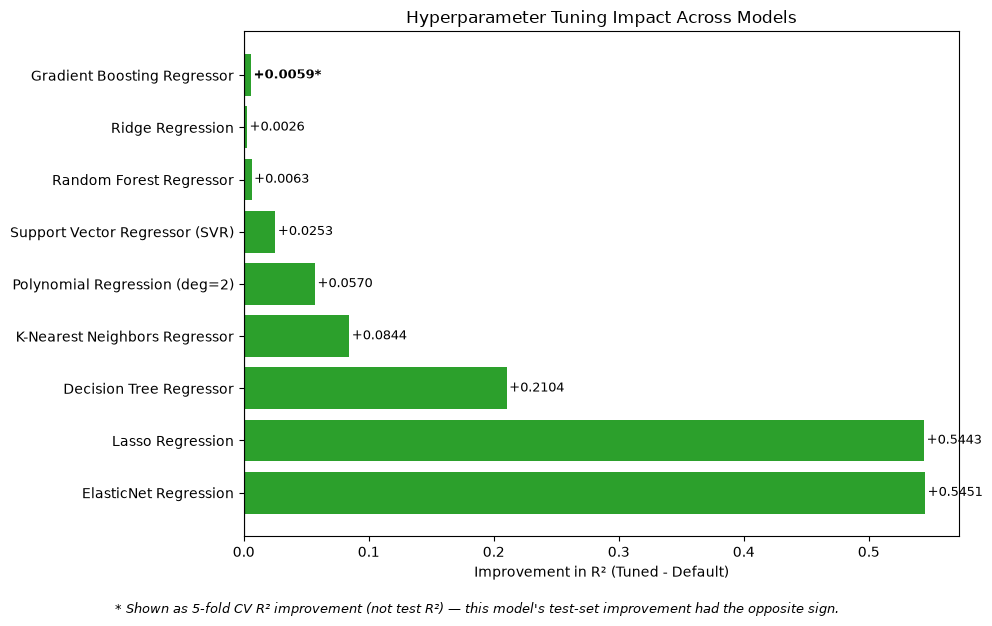

,Model,Improvement,Plotted_Improvement,Flag
0,ElasticNet Regression,0.545067,0.545067,
1,Lasso Regression,0.544294,0.544294,
2,Decision Tree Regressor,0.210352,0.210352,
3,K-Nearest Neighbors Regressor,0.084446,0.084446,
4,Polynomial Regression (deg=2),0.057029,0.057029,
5,Support Vector Regressor (SVR),0.025318,0.025318,
6,Random Forest Regressor,0.006309,0.006309,
7,Ridge Regression,0.002650,0.002650,
8,Gradient Boosting Regressor,-0.018077,0.005900,*


In [42]:


tuning_df = pd.DataFrame(tuning_improvements).sort_values(by="Improvement", ascending=False).reset_index(drop=True)


cv_improvements = {
    "Gradient Boosting Regressor": 0.7107 - 0.7048 
}

tuning_df["Plotted_Improvement"] = tuning_df.apply(
    lambda row: cv_improvements[row["Model"]] if row["Model"] in cv_improvements else row["Improvement"],
    axis=1
)
tuning_df["Flag"] = tuning_df["Model"].apply(lambda m: "*" if m in cv_improvements else "")

plt.figure(figsize=(10, 6))
colors = ['#2ca02c' if x >= 0 else '#d62728' for x in tuning_df["Plotted_Improvement"]]
bars = plt.barh(tuning_df["Model"], tuning_df["Plotted_Improvement"], color=colors)

plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel("Improvement in R² (Tuned - Default)")
plt.title("Hyperparameter Tuning Impact Across Models")

# Add value labels + asterisk for flagged bars
for bar, flag, val in zip(bars, tuning_df["Flag"], tuning_df["Plotted_Improvement"]):
    label = f"{val:+.4f}{flag}"
    offset = 0.002 if val >= 0 else -0.002
    ha = 'left' if val >= 0 else 'right'
    plt.annotate(
        label,
        xy=(val + offset, bar.get_y() + bar.get_height() / 2),
        fontsize=9, fontweight='bold' if flag else 'normal',
        ha=ha, va='center'
    )

plt.figtext(
    0.12, -0.03,
    "* Shown as 5-fold CV R² improvement (not test R²) — this model's test-set improvement had the opposite sign.",
    fontsize=9, style='italic'
)

plt.tight_layout()
plt.show()

tuning_df[["Model", "Improvement", "Plotted_Improvement", "Flag"]]

## Analysis 

### 1. Comparision of metrics across 10 models

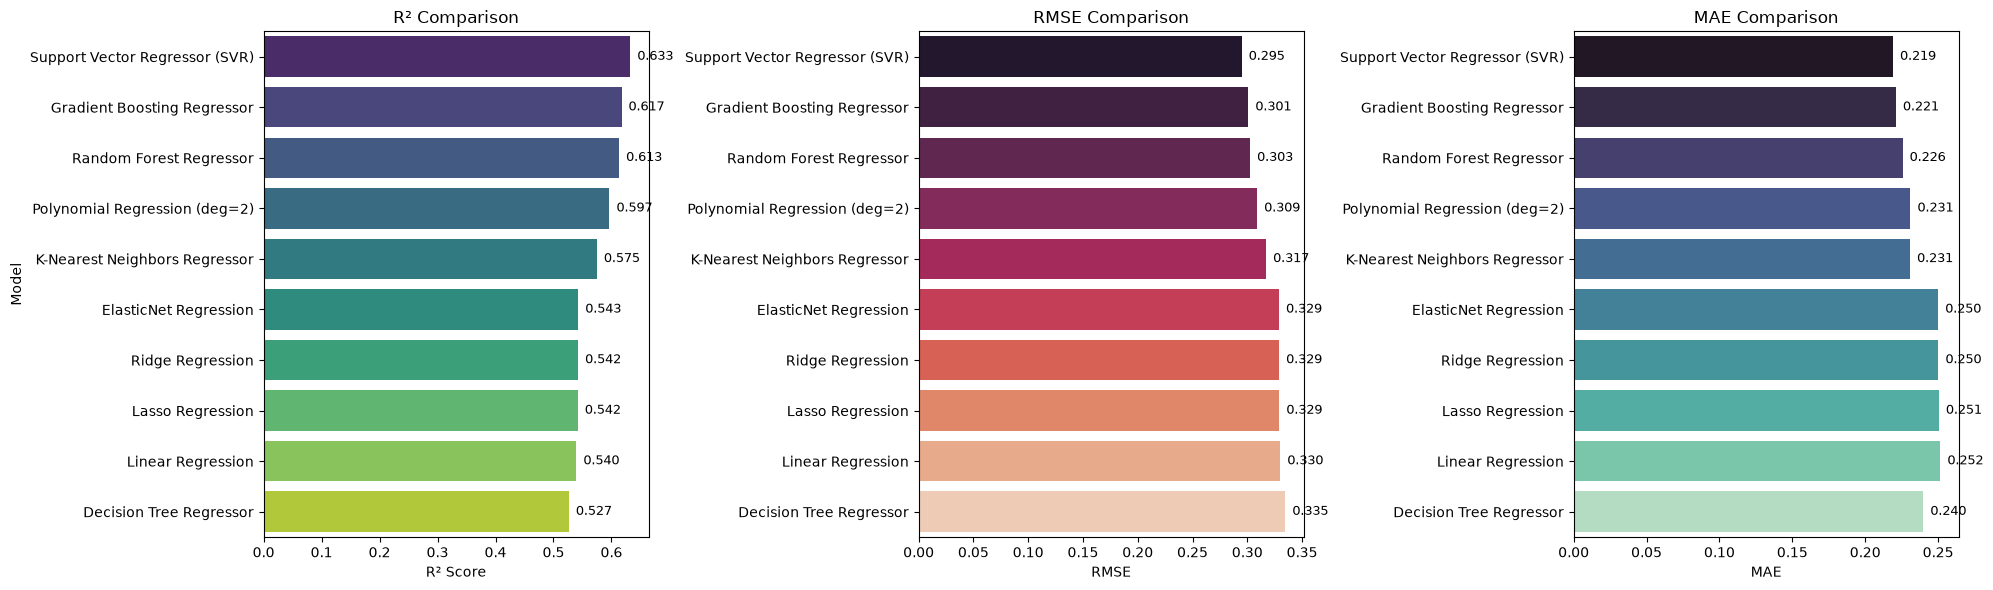

In [43]:
results_df = pd.DataFrame(all_results).sort_values(by="R2", ascending=False).reset_index(drop=True)
results_df.insert(0, "Rank", range(1, len(results_df) + 1))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

metrics_config = [
    ("R2", axes[0], "viridis", "R² Comparison", "R² Score"),
    ("RMSE", axes[1], "rocket", "RMSE Comparison", "RMSE"),
    ("MAE", axes[2], "mako", "MAE Comparison", "MAE"),
]

for metric, ax, palette, title, xlabel in metrics_config:
    sns.barplot(data=results_df, x=metric, y="Model", ax=ax, palette=palette, hue="Model", legend=False)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    if metric != "R2":
        ax.set_ylabel("")

    for i, val in enumerate(results_df[metric]):
        ax.annotate(
            f'{val:.3f}',
            xy=(val, i),
            xytext=(5, 0),
            textcoords="offset points",
            ha='left', va='center',
            fontsize=9
        )

plt.tight_layout()
plt.show()

>**Insight:** We observe that SVR is the highest performing model across all three metrics

Top 2 models by test R²: ['Support Vector Regressor (SVR)', 'Gradient Boosting Regressor']


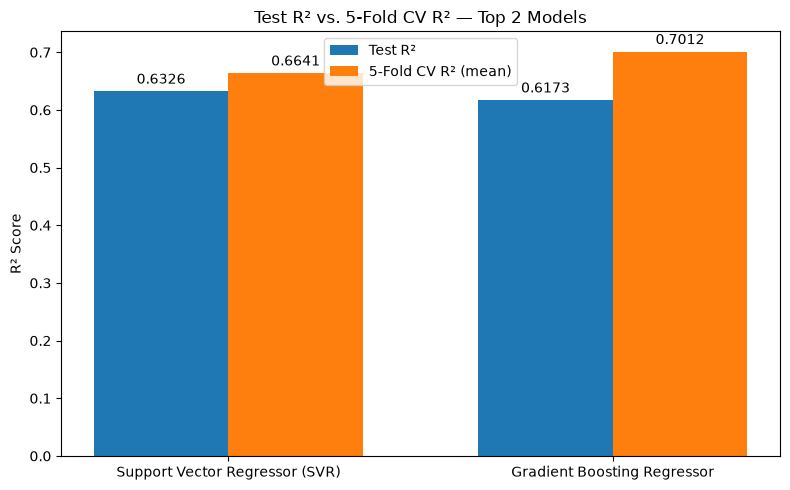

In [44]:
cv_score_lookup = {
    "Ridge Regression": ridge_grid.best_score_,
    "Lasso Regression": lasso_grid.best_score_,
    "ElasticNet Regression": elastic_grid.best_score_,
    "Decision Tree Regressor": tree_grid.best_score_,
    "Random Forest Regressor": rf_grid.best_score_,
    "Gradient Boosting Regressor": gb_grid.best_score_,
    "Support Vector Regressor (SVR)": svr_grid.best_score_,
    "K-Nearest Neighbors Regressor": knn_grid.best_score_,
}

top_2_models = results_df.head(2)["Model"].tolist()
print("Top 2 models by test R²:", top_2_models)

cv_comparison = []
for model_name in top_2_models:
    test_r2 = results_df.loc[results_df["Model"] == model_name, "R2"].values[0]

    if model_name in cv_score_lookup:
        cv_r2 = cv_score_lookup[model_name]
    else:
        model_obj = model_lookup_final.get(model_name, None)
        if model_obj is not None:
            cv_scores = cross_val_score(
                model_obj, X_train_processed, y_train,
                cv=group_cv, groups=train_groups, scoring='r2', n_jobs=-1
            )
            cv_r2 = cv_scores.mean()
        else:
            cv_r2 = np.nan

    cv_comparison.append({
        "Model": model_name,
        "Test R2": test_r2,
        "5-Fold CV R2 (mean)": cv_r2
    })

cv_comparison_df = pd.DataFrame(cv_comparison)
cv_comparison_df


plt.figure(figsize=(8, 5))
x = np.arange(len(cv_comparison_df))
width = 0.35

bars1 = plt.bar(x - width/2, cv_comparison_df["Test R2"], width, label="Test R²")
bars2 = plt.bar(x + width/2, cv_comparison_df["5-Fold CV R2 (mean)"], width, label="5-Fold CV R² (mean)")

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.annotate(
            f'{height:.4f}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),  
            textcoords="offset points",
            ha='center', va='bottom',
            fontsize=10
        )

plt.xticks(x, cv_comparison_df["Model"])
plt.ylabel("R² Score")
plt.title("Test R² vs. 5-Fold CV R² — Top 2 Models")
plt.legend()
plt.tight_layout()
plt.show()

### 2. Understanding how optimal k for KNN was derived

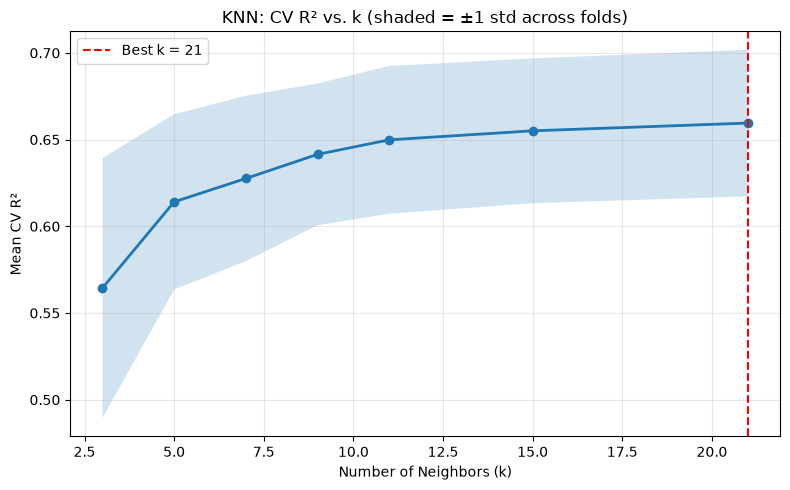

In [45]:
knn_cv_results = pd.DataFrame(knn_grid.cv_results_)
knn_cv_results['k'] = knn_cv_results['param_n_neighbors']
knn_cv_results = knn_cv_results.sort_values(by='k')

plt.figure(figsize=(8, 5))

plt.plot(
    knn_cv_results['k'],
    knn_cv_results['mean_test_score'],
    marker='o',
    linewidth=2
)

plt.fill_between(
    knn_cv_results['k'],
    knn_cv_results['mean_test_score'] - knn_cv_results['std_test_score'],
    knn_cv_results['mean_test_score'] + knn_cv_results['std_test_score'],
    alpha=0.2
)

best_k = knn_grid.best_params_['n_neighbors']
best_score = knn_grid.best_score_

plt.axvline(x=best_k, color='red', linestyle='--', linewidth=1.5,
            label=f'Best k = {best_k}')

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Mean CV R²")
plt.title("KNN: CV R² vs. k (shaded = ±1 std across folds)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3. Explainabity of SVR using permutation importance on R2

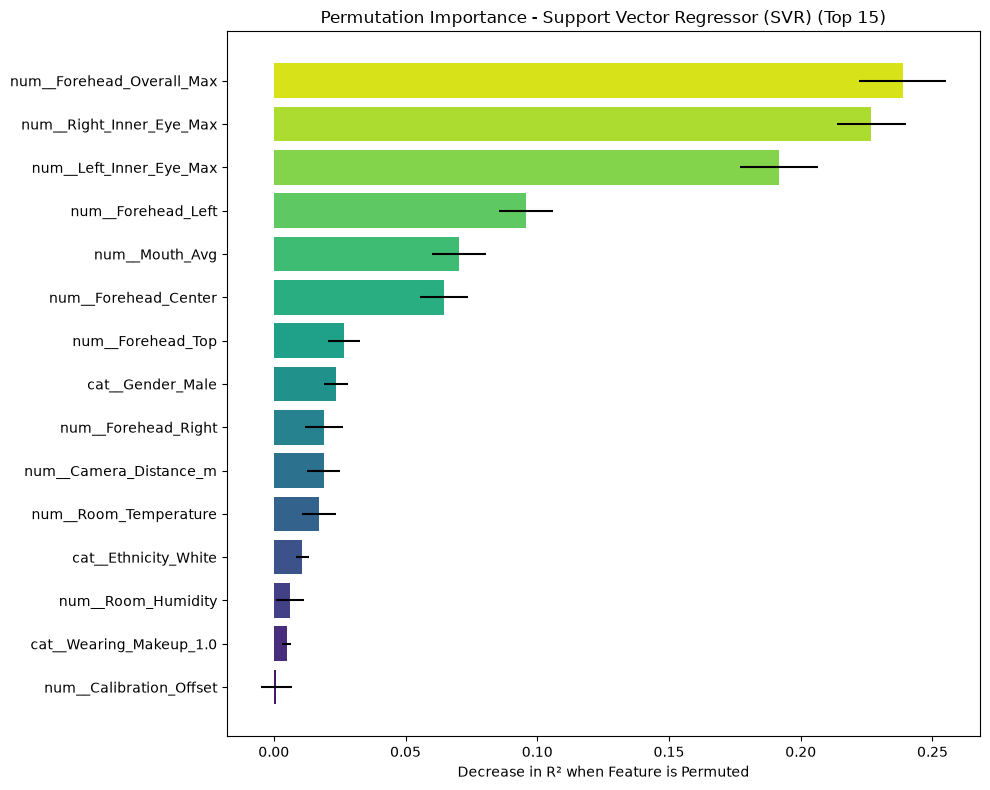

,Feature,Importance_Mean,Importance_Std
9,num__Forehead_Overall_Max,0.238653,0.016385
1,num__Right_Inner_Eye_Max,0.226716,0.013127
2,num__Left_Inner_Eye_Max,0.191901,0.014834
7,num__Forehead_Left,0.095718,0.010172
10,num__Mouth_Avg,0.070140,0.010228
5,num__Forehead_Center,0.064685,0.009106
8,num__Forehead_Top,0.026705,0.006162
14,cat__Gender_Male,0.023635,0.004660
6,num__Forehead_Right,0.019169,0.007282
13,num__Camera_Distance_m,0.018881,0.006400


In [46]:
from sklearn.inspection import permutation_importance

model_lookup_final = {
    "Linear Regression": linear_model,
    "Ridge Regression": ridge_model,
    "Lasso Regression": lasso_model,
    "ElasticNet Regression": elastic_model,
    "Decision Tree Regressor": tree_model,
    "Random Forest Regressor": rf_model,
    "Gradient Boosting Regressor": gb_model,
    "Support Vector Regressor (SVR)": svr_model,
    "K-Nearest Neighbors Regressor": knn_model,
}

best_model_name = results_df.loc[0, "Model"]
best_model = model_lookup_final[best_model_name]

perm_result = permutation_importance(
    best_model,
    X_test_processed,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring='r2',
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    "Feature": encoded_feature_names,
    "Importance_Mean": perm_result.importances_mean,
    "Importance_Std": perm_result.importances_std
}).sort_values(by="Importance_Mean", ascending=False)

plt.figure(figsize=(10, 8))

plt.barh(
    perm_importance_df["Feature"][:15][::-1],
    perm_importance_df["Importance_Mean"][:15][::-1],
    xerr=perm_importance_df["Importance_Std"][:15][::-1],
    color=sns.color_palette("viridis", 15)
)

plt.xlabel("Decrease in R² when Feature is Permuted")
plt.title(f"Permutation Importance - {best_model_name} (Top 15)")
plt.tight_layout()
plt.show()

perm_importance_df.head(15)

### 4. Feature importance on a tree based model, comparing mean decrease in impurity and decrease in R2

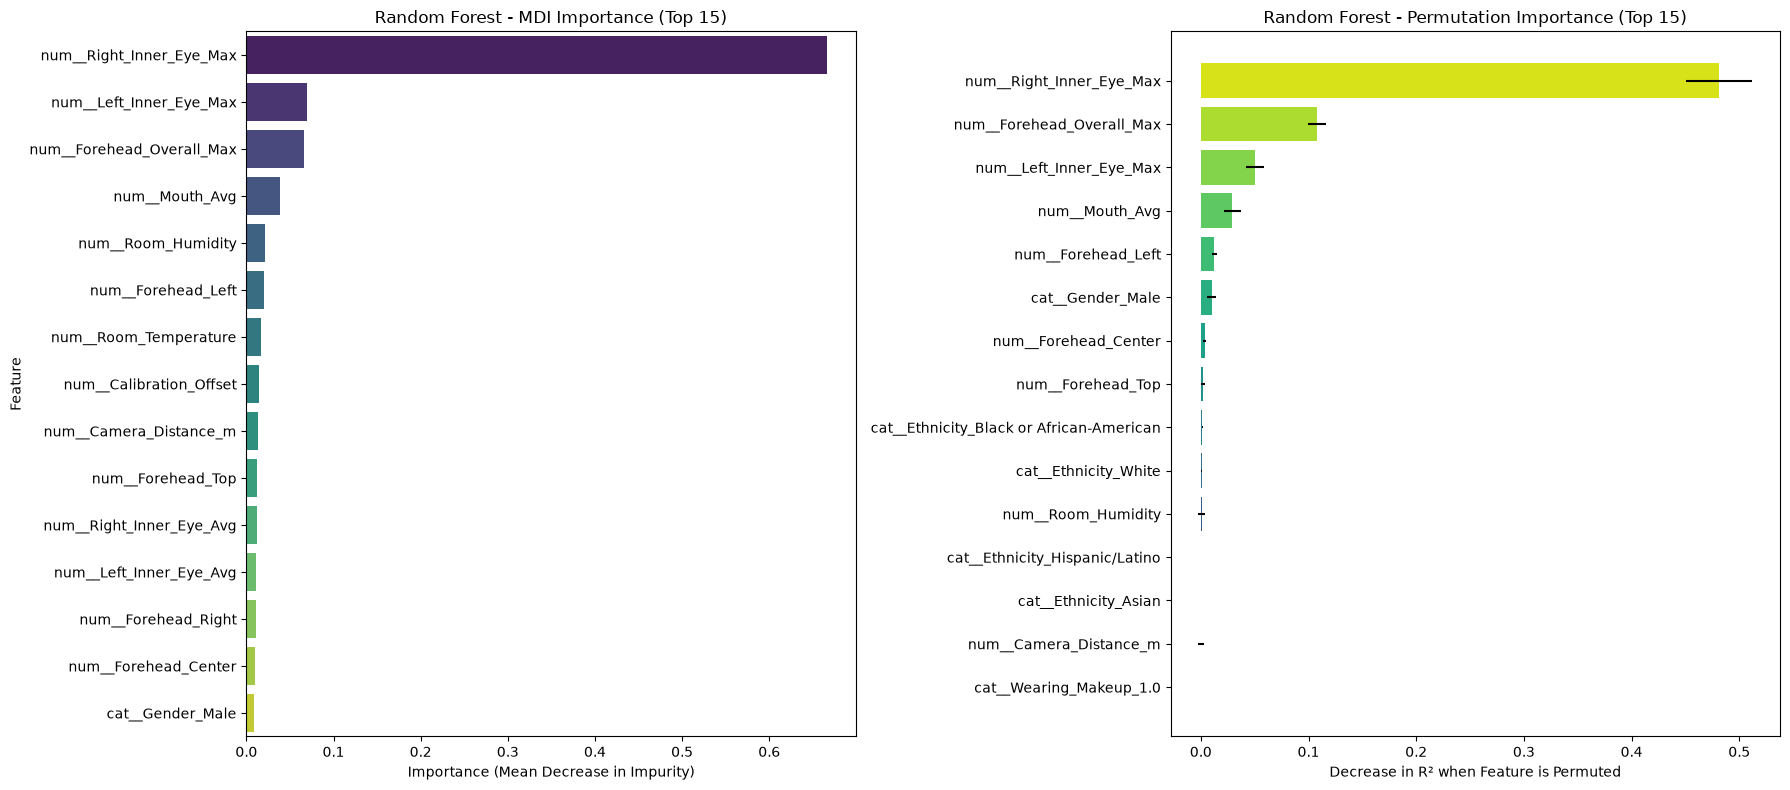

In [47]:
rf_importance_df = pd.DataFrame({
    "Feature": encoded_feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False).head(15)


rf_perm = permutation_importance(
    rf_model, X_test_processed, y_test,
    n_repeats=30, random_state=42, scoring='r2', n_jobs=-1
)

rf_perm_df = pd.DataFrame({
    "Feature": encoded_feature_names,
    "Importance": rf_perm.importances_mean,
    "Std": rf_perm.importances_std
}).sort_values(by="Importance", ascending=False).head(15)


fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.barplot(
    data=rf_importance_df,
    x="Importance", y="Feature",
    palette="viridis", ax=axes[0],
    hue="Feature", legend=False
)
axes[0].set_title("Random Forest - MDI Importance (Top 15)")
axes[0].set_xlabel("Importance (Mean Decrease in Impurity)")
axes[0].set_ylabel("Feature")

axes[1].barh(
    rf_perm_df["Feature"][::-1],
    rf_perm_df["Importance"][::-1],
    xerr=rf_perm_df["Std"][::-1],
    color=sns.color_palette("viridis", 15)
)
axes[1].set_title("Random Forest - Permutation Importance (Top 15)")
axes[1].set_xlabel("Decrease in R² when Feature is Permuted")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### 5. Predicted vs Actual for SVR

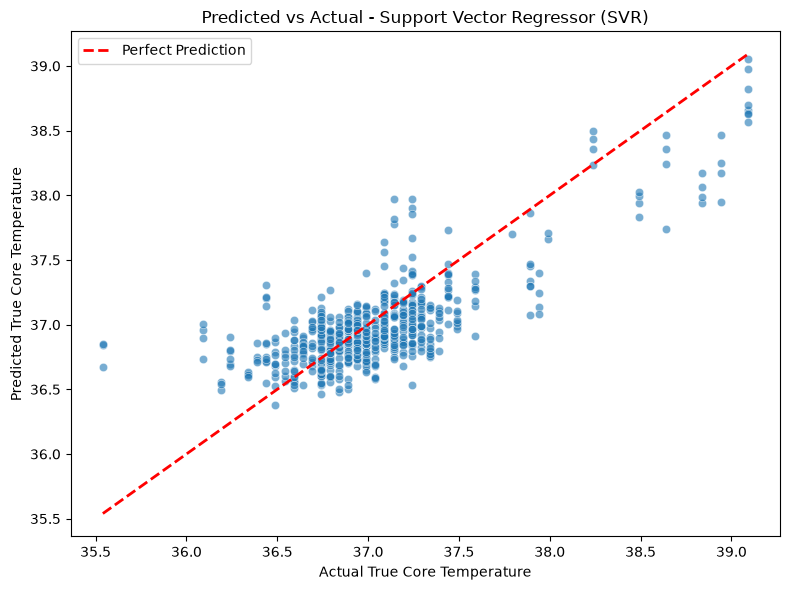

In [48]:
best_predictions = best_model.predict(X_test_processed)

plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_test, y=best_predictions, alpha=0.6)

min_val = min(y_test.min(), best_predictions.min())
max_val = max(y_test.max(), best_predictions.max())

plt.plot([min_val, max_val], [min_val, max_val],
         linestyle='--', linewidth=2, color='red', label='Perfect Prediction')

plt.xlabel("Actual True Core Temperature")
plt.ylabel("Predicted True Core Temperature")
plt.title(f"Predicted vs Actual - {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

### 6. Residual plots for SVR

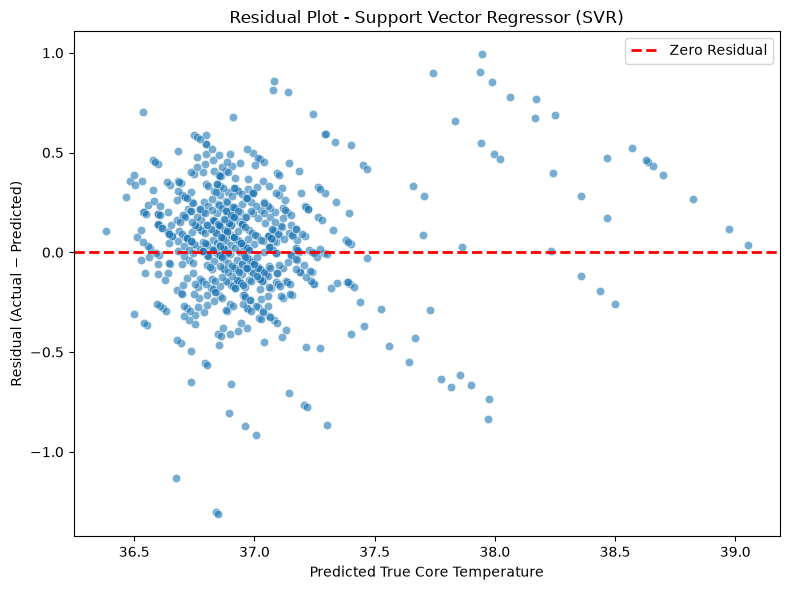

In [49]:
residuals = y_test - best_predictions

plt.figure(figsize=(8, 6))

sns.scatterplot(x=best_predictions, y=residuals, alpha=0.6)

plt.axhline(y=0, linestyle='--', linewidth=2, color='red', label='Zero Residual')

plt.xlabel("Predicted True Core Temperature")
plt.ylabel("Residual (Actual − Predicted)")
plt.title(f"Residual Plot - {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

### Feature Engineering

In [50]:
model_configs = {
    "Ridge Regression": (Ridge(), {'alpha': [0.1, 1.0, 10.0, 50.0]}),
    "Random Forest Regressor": (RandomForestRegressor(random_state=42, n_jobs=-1),
                                  {'n_estimators': [200], 'max_depth': [10, None]}),
    "Gradient Boosting Regressor": (GradientBoostingRegressor(random_state=42),
                                      {'n_estimators': [200], 'learning_rate': [0.05], 'max_depth': [3]}),
    "Support Vector Regressor (SVR)": (SVR(), {'C': [1, 10, 100], 'kernel': ['rbf'], 'gamma': ['scale']}),
    "K-Nearest Neighbors Regressor": (KNeighborsRegressor(), {'n_neighbors': [5, 9, 15]}),
}

baseline_preds = {
    "Ridge Regression": ridge_model,
    "Random Forest Regressor": rf_model,
    "Gradient Boosting Regressor": gb_model,
    "Support Vector Regressor (SVR)": svr_model,
    "K-Nearest Neighbors Regressor": knn_model,
}

In [51]:
train_v3 = train_model_data.copy()
test_v3 = test_model_data.copy()

for data_split in [train_v3, test_v3]:
    inner_eye_avg = data_split[['Right_Inner_Eye_Max', 'Left_Inner_Eye_Max']].mean(axis=1)

    # Physiological differential: perfusion-driven (eye) vs. convection-exposed (forehead) regions
    data_split['Eye_Forehead_Diff'] = inner_eye_avg - data_split['Forehead_Overall_Max']

    # Nonlinear humidity effect: emissivity/attenuation may behave nonlinearly, not linearly
    data_split['Humidity_Squared'] = data_split['Room_Humidity'] ** 2

    # Temp-humidity interaction: combined ambient effect (heat-index style), not purely additive
    data_split['Temp_x_Humidity'] = data_split['Room_Temperature'] * data_split['Room_Humidity']

    # Ambient-gradient modulated by humidity, rather than gradient alone
    data_split['Gradient_x_Humidity'] = (inner_eye_avg - data_split['Room_Temperature']) * data_split['Room_Humidity']

    # Log-scaled humidity: dampens extreme-humidity influence vs. a linear term
    data_split['Log_Humidity'] = np.log1p(data_split['Room_Humidity'])

engineered_feature_cols = [
    'Eye_Forehead_Diff', 'Humidity_Squared', 'Temp_x_Humidity',
    'Gradient_x_Humidity', 'Log_Humidity'
]

feature_cols_v3 = feature_cols + engineered_feature_cols
numerical_cols_v3 = numerical_cols + engineered_feature_cols

X_train_v3 = train_v3[feature_cols_v3]
X_test_v3 = test_v3[feature_cols_v3]


In [52]:
preprocessor_v3 = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols_v3),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

X_train_v3_processed = preprocessor_v3.fit_transform(X_train_v3)
X_test_v3_processed = preprocessor_v3.transform(X_test_v3)

print(f"Engineered feature set: {X_train_v3_processed.shape[1]} columns "
      f"(baseline was {X_train_processed.shape[1]})")


feature_impact_results = []

for model_name, (estimator, param_grid) in model_configs.items():
    baseline_model = baseline_preds[model_name]
    baseline_r2 = r2_score(y_test, baseline_model.predict(X_test_processed))

    tuned_grid = GridSearchCV(estimator, param_grid, cv=group_cv, scoring='r2', n_jobs=-1)
    tuned_grid.fit(X_train_v3_processed, y_train, groups=train_groups)
    engineered_r2 = r2_score(y_test, tuned_grid.best_estimator_.predict(X_test_v3_processed))

    feature_impact_results.append({
        "Model": model_name,
        "Baseline R2": baseline_r2,
        "Engineered R2": engineered_r2,
        "Improvement": engineered_r2 - baseline_r2
    })

    print(f"{model_name}: {baseline_r2:.4f} -> {engineered_r2:.4f} ({engineered_r2 - baseline_r2:+.4f})")

feature_impact_df = pd.DataFrame(feature_impact_results).sort_values(
    by="Improvement", ascending=False
).reset_index(drop=True)

Engineered feature set: 26 columns (baseline was 21)
Ridge Regression: 0.5425 -> 0.5438 (+0.0013)
Random Forest Regressor: 0.6132 -> 0.6067 (-0.0065)
Gradient Boosting Regressor: 0.6173 -> 0.6312 (+0.0139)
Support Vector Regressor (SVR): 0.6326 -> 0.5910 (-0.0416)
K-Nearest Neighbors Regressor: 0.5749 -> 0.5449 (-0.0300)


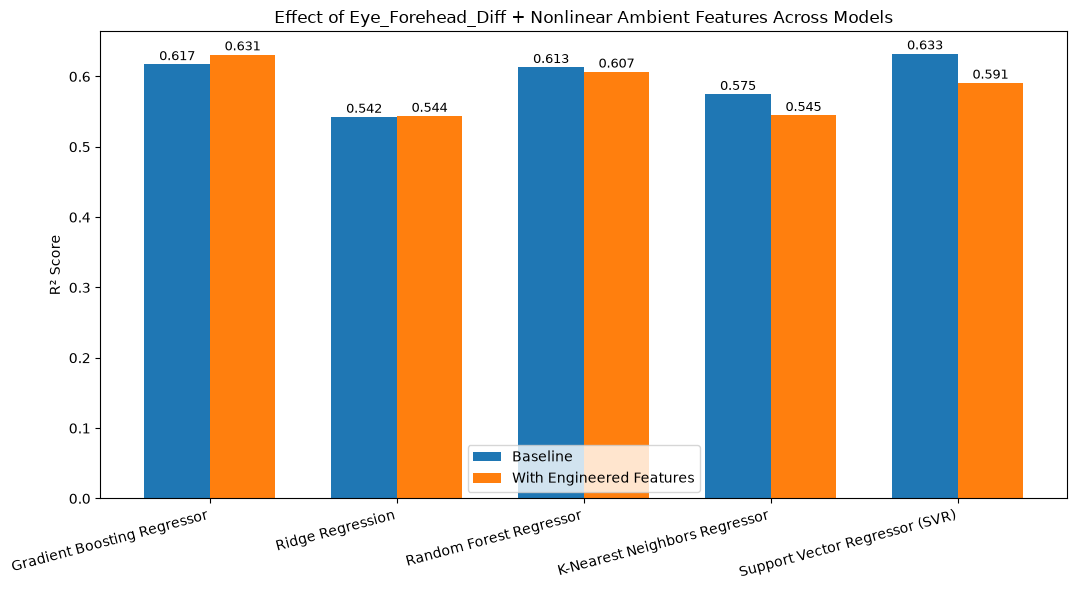

,Model,Baseline R2,Engineered R2,Improvement
0,Gradient Boosting Regressor,0.617296,0.631185,0.013889
1,Ridge Regression,0.542498,0.543819,0.001321
2,Random Forest Regressor,0.613218,0.606675,-0.006542
3,K-Nearest Neighbors Regressor,0.574891,0.544938,-0.029953
4,Support Vector Regressor (SVR),0.632562,0.590974,-0.041588


In [53]:
plt.figure(figsize=(11, 6))
x_pos = np.arange(len(feature_impact_df))
bar_width = 0.35

baseline_bars = plt.bar(x_pos - bar_width/2, feature_impact_df["Baseline R2"],
                          bar_width, label="Baseline")
engineered_bars = plt.bar(x_pos + bar_width/2, feature_impact_df["Engineered R2"],
                            bar_width, label="With Engineered Features")

for bar_group in [baseline_bars, engineered_bars]:
    for bar in bar_group:
        height = bar.get_height()
        plt.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                     xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.xticks(x_pos, feature_impact_df["Model"], rotation=15, ha='right')
plt.ylabel("R² Score")
plt.title("Effect of Eye_Forehead_Diff + Nonlinear Ambient Features Across Models")
plt.legend()
plt.tight_layout()
plt.show()

feature_impact_df

In [54]:
import joblib, os

ART = "../deployment/artifacts"
os.makedirs(ART, exist_ok=True)

models = {
    "Linear Regression": linear_model,
    "Ridge Regression": ridge_model,
    "Lasso Regression": lasso_model,
    "ElasticNet Regression": elastic_model,
    "Polynomial Regression (deg=2)": polynomial_model,
    "Decision Tree Regressor": tree_model,
    "Random Forest Regressor": rf_model,
    "Gradient Boosting Regressor": gb_model,
    "Support Vector Regressor (SVR)": svr_model,
    "K-Nearest Neighbors Regressor": knn_model,
}

meta = {
    "feature_cols": feature_cols,
    "gender": sorted(X_train["Gender"].unique().tolist()),
    "ethnicity": sorted(X_train["Ethnicity"].unique().tolist()),
    "makeup": sorted(X_train["Wearing_Makeup"].unique().tolist()),
    "numerical_cols": numerical_cols,
    "num_stats": X_train[numerical_cols].describe().loc[["min", "max", "mean"]].to_dict(),
}

joblib.dump(preprocessor, f"{ART}/preprocessor.joblib")
joblib.dump(models,       f"{ART}/models.joblib")
joblib.dump(meta,         f"{ART}/meta.joblib")
results_df.to_csv(f"{ART}/metrics.csv", index=False)

print("Saved:", os.listdir(ART))
print("Model names in metrics:", results_df["Model"].tolist())

Saved: ['meta.joblib', 'metrics.csv', 'models.joblib', 'preprocessor.joblib']
Model names in metrics: ['Support Vector Regressor (SVR)', 'Gradient Boosting Regressor', 'Random Forest Regressor', 'Polynomial Regression (deg=2)', 'K-Nearest Neighbors Regressor', 'ElasticNet Regression', 'Ridge Regression', 'Lasso Regression', 'Linear Regression', 'Decision Tree Regressor']
